# 🦠 Pipeline Professionnel de Forecasting Épidémiologique — Tuberculose Mondiale

---

## 📋 Description du Projet

Ce notebook implémente un **pipeline complet de séries temporelles** pour l'analyse et la prévision des cas de tuberculose (TB) dans **11 pays à forte charge mondiale**.

### 🎯 Objectifs
- Analyser les tendances temporelles de la tuberculose
- Comparer des modèles statistiques (ARIMA, SARIMA, SARIMAX) et Machine Learning (XGBoost, LightGBM)
- Détecter les anomalies (COVID, sous-déclarations)
- Générer des prévisions sur 12 et 24 mois
- Déployer un dashboard Streamlit interactif

### 🌍 Pays Étudiés
India · China · Indonesia · Pakistan · Nigeria · Bangladesh · South Africa · Philippines · DR Congo · Ethiopia · Morocco

### 📊 Variable Cible : `TB_Cases`

---

> **Note :** Ce notebook est directement exécutable dans Google Colab. Toutes les étapes sont automatisées.


## 📦 Section 1 — Installation des Bibliothèques

Installation de toutes les dépendances nécessaires au pipeline de forecasting épidémiologique.


In [3]:
# ============================================================
# INSTALLATION DES BIBLIOTHÈQUES
# ============================================================

print("📦 Installation des bibliothèques en cours...")

import subprocess, sys

packages = [
    'statsmodels', 'pmdarima', 'xgboost', 'lightgbm',
    'plotly', 'kaleido', 'openpyxl', 'tqdm',
    'streamlit', 'scikit-learn'
]

for pkg in packages:
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'  ✅ {pkg} installé')
    except Exception as e:
        print(f'  ⚠️ Erreur {pkg} : {e}')

print("\n✅ Installation terminée.")

📦 Installation des bibliothèques en cours...
  ✅ statsmodels installé
  ✅ pmdarima installé
  ✅ xgboost installé
  ✅ lightgbm installé
  ✅ plotly installé
  ✅ kaleido installé
  ✅ openpyxl installé
  ✅ tqdm installé
  ✅ streamlit installé
  ✅ scikit-learn installé

✅ Installation terminée.


## 📚 Section 2 — Importation des Modules


In [4]:
# ============================================================
# IMPORTATION DES MODULES
# ============================================================

import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd
import gc
import os
import pickle
from datetime import datetime
from tqdm import tqdm

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistiques & Tests
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Machine Learning
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb

# Style global
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
COLORS = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
          '#44BBA4', '#E94F37', '#393E41', '#F5A623', '#7B2D8B', '#1A936F']

print("✅ Tous les modules importés avec succès.")
print(f"📅 Date d'exécution : {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}")

✅ Tous les modules importés avec succès.
📅 Date d'exécution : 23/05/2026 12:37:51


## ☁️ Section 3 — Connexion Google Drive & Chargement des Données

Montage automatique de Google Drive et chargement du fichier Excel `TB_Global_Weekly_Dataset.xlsx`.


In [5]:
# ============================================================
# MONTAGE GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# Chemin du fichier
FILE_PATH = '/content/drive/MyDrive/project_time_series/TB_Global_Weekly_Dataset.xlsx'
SHEET_NAME = 'TB_Weekly_Data'
OUTPUT_DIR = '/content/drive/MyDrive/project_time_series/outputs/'

# Création du répertoire de sortie
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR + 'models/', exist_ok=True)

print(f"✅ Google Drive monté")
print(f"📂 Fichier : {FILE_PATH}")
print(f"📁 Sorties : {OUTPUT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive monté
📂 Fichier : /content/drive/MyDrive/project_time_series/TB_Global_Weekly_Dataset.xlsx
📁 Sorties : /content/drive/MyDrive/project_time_series/outputs/


In [6]:
# ============================================================
# CHARGEMENT DU DATASET
# ============================================================

print("📖 Chargement du dataset TB mondial...")

try:
    df_raw = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)
    print(f"✅ Dataset chargé : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes")
except FileNotFoundError:
    print("⚠️ Fichier non trouvé. Génération d'un dataset simulé pour démonstration...")

    # ---- DATASET SIMULÉ POUR DÉMONSTRATION ----
    np.random.seed(42)
    COUNTRIES = ['India','China','Indonesia','Pakistan','Nigeria','Bangladesh',
                 'South Africa','Philippines','DR Congo','Ethiopia','Morocco']
    dates = pd.date_range('2015-01-05', '2023-12-25', freq='W')

    base_cases = {'India':2500000,'China':800000,'Indonesia':900000,'Pakistan':600000,
                  'Nigeria':700000,'Bangladesh':400000,'South Africa':300000,
                  'Philippines':500000,'DR Congo':350000,'Ethiopia':280000,'Morocco':40000}
    rows = []
    for country in COUNTRIES:
        base = base_cases[country]
        for i, date in enumerate(dates):
            trend = 1 - 0.002 * (i / 52)
            season = 1 + 0.1 * np.sin(2 * np.pi * i / 52)
            covid_shock = 0.7 if ('2020' in str(date) or '2021' in str(date)[:4]) else 1.0
            noise = np.random.normal(1, 0.05)
            cases = max(0, int(base / 52 * trend * season * covid_shock * noise))
            deaths = max(0, int(cases * np.random.uniform(0.08, 0.15)))
            rows.append({
                'Country': country, 'Date': date,
                'TB_Cases': cases, 'TB_Deaths': deaths,
                'Population': np.random.uniform(5e7, 1.4e9),
                'TB_Incidence_Rate': cases / 1e5 * np.random.uniform(0.8, 1.2),
                'Healthcare_Index': np.random.uniform(20, 85),
                'Vaccination_Rate': np.random.uniform(30, 95),
                'GDP_Per_Capita': np.random.uniform(500, 15000),
                'Urbanization_Rate': np.random.uniform(20, 80),
                'HIV_Prevalence': np.random.uniform(0.1, 20),
                'Reporting_Quality': np.random.uniform(40, 95)
            })
    df_raw = pd.DataFrame(rows)
    print(f"✅ Dataset simulé généré : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes")

df_raw.head(3)

📖 Chargement du dataset TB mondial...
✅ Dataset chargé : 239,323 lignes × 15 colonnes


,Country,ISO_Code,Date,Year,Week,Population,TB_Cases,TB_Deaths,TB_Incidence_Rate,Healthcare_Index,Vaccination_Rate,GDP_Per_Capita,Urbanization_Rate,HIV_Prevalence,Reporting_Quality
0,Afghanistan,AFG,2003-01-01,2003,1,6320650,423,106,342.9588,0.3701,0.7791,2799.66,0.4307,0.016026,0.4035
1,Afghanistan,AFG,2003-01-08,2003,2,6322571,358,72,293.2953,0.3692,0.8191,2826.41,0.4339,0.016059,0.3869
2,Afghanistan,AFG,2003-01-15,2003,3,6324492,256,50,227.3978,0.3734,0.7848,2894.96,0.4379,0.015926,0.3922


## 🔍 Section 4 — Exploration & Nettoyage des Données

### Pourquoi explorer avant de modéliser ?
L'exploration permet d'identifier : les valeurs manquantes, les outliers, la structure temporelle, et les corrélations entre variables. Dans les données épidémiologiques, des biais de déclaration ou des chocs exogènes (ex. COVID) peuvent fortement perturber les séries.


In [7]:
# ============================================================
# FILTRAGE — 11 PAYS SÉLECTIONNÉS
# ============================================================

PAYS_CIBLES = [
    'India', 'China', 'Indonesia', 'Pakistan', 'Nigeria',
    'Bangladesh', 'South Africa', 'Philippines',
    'DR Congo', 'Ethiopia', 'Morocco'
]

# Conversion de la colonne Date
df_raw['Date'] = pd.to_datetime(df_raw['Date'])

# Filtrage des pays cibles
df = df_raw[df_raw['Country'].isin(PAYS_CIBLES)].copy()
df = df.sort_values(['Country', 'Date']).reset_index(drop=True)

print("=" * 55)
print("RÉSUMÉ DU DATASET FILTRÉ")
print("=" * 55)
print(f"  Lignes totales    : {df.shape[0]:,}")
print(f"  Colonnes          : {df.shape[1]}")
print(f"  Pays              : {df['Country'].nunique()}")
print(f"  Période           : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"  Valeurs manquantes: {df.isnull().sum().sum()}")
print("="*55)

# Statistiques descriptives
print("\n📊 Statistiques descriptives — TB_Cases par pays :")
df.groupby('Country')['TB_Cases'].describe().round(0).astype(int)

RÉSUMÉ DU DATASET FILTRÉ
  Lignes totales    : 13,783
  Colonnes          : 15
  Pays              : 11
  Période           : 2003-01-01 → 2026-12-30
  Valeurs manquantes: 0

📊 Statistiques descriptives — TB_Cases par pays :


,count,mean,std,min,25%,50%,75%,max
Country,,,,,,,,
Bangladesh,1253,6956,1152,1681,6212,6833,7511,22005
China,1253,18921,3696,10075,16540,18734,21091,56947
DR Congo,1253,3803,901,838,3156,3702,4340,13547
Ethiopia,1253,8915,1679,1915,7767,8679,9870,27857
India,1253,60525,10270,20668,55029,59818,64515,175409
Indonesia,1253,13473,1972,3258,12338,13306,14431,39274
Morocco,1253,208,35,132,184,204,228,520
Nigeria,1253,11409,1893,2762,10317,11252,12264,34394
Pakistan,1253,5579,914,1412,4963,5505,6067,15212


In [8]:
# ============================================================
# NETTOYAGE — VALEURS MANQUANTES & DOUBLONS
# ============================================================

# Suppression des doublons
doublons = df.duplicated(subset=['Country','Date']).sum()
print(f"🔁 Doublons détectés : {doublons}")
df = df.drop_duplicates(subset=['Country','Date'])

# Gestion des valeurs manquantes (interpolation linéaire)
VARS_NUM = ['TB_Cases','TB_Deaths','Population','TB_Incidence_Rate',
            'Healthcare_Index','Vaccination_Rate','GDP_Per_Capita',
            'Urbanization_Rate','HIV_Prevalence','Reporting_Quality']

for country in df['Country'].unique():
    mask = df['Country'] == country
    df.loc[mask, VARS_NUM] = df.loc[mask, VARS_NUM].interpolate(method='linear')

df[VARS_NUM] = df[VARS_NUM].fillna(method='bfill').fillna(method='ffill')
print(f"✅ Valeurs manquantes après interpolation : {df[VARS_NUM].isnull().sum().sum()}")

print("\n✅ Données nettoyées et prêtes.")

🔁 Doublons détectés : 0
✅ Valeurs manquantes après interpolation : 0

✅ Données nettoyées et prêtes.


## 📅 Section 5 — Conversion Hebdomadaire → Mensuelle

### Pourquoi agréger en mensuel ?
Les données hebdomadaires contiennent beaucoup de bruit à court terme (week-end, jours fériés, délais de déclaration). L'agrégation mensuelle :
- **Réduit le bruit** stochastique
- **Améliore la stationnarité** de la série
- **Aligne** les données sur les cycles épidémiologiques naturels (saisonnalité annuelle s=12)
- **Facilite** la comparaison entre pays avec des systèmes de santé différents


In [9]:
# ============================================================
# CONVERSION HEBDOMADAIRE → MENSUELLE
# ============================================================

print("📅 Conversion des données hebdomadaires en mensuelles...")

df_monthly = (
    df.groupby('Country')
      .resample('M', on='Date')
      .agg({
          'TB_Cases':           'sum',
          'TB_Deaths':          'sum',
          'Population':         'mean',
          'TB_Incidence_Rate':  'mean',
          'Healthcare_Index':   'mean',
          'Vaccination_Rate':   'mean',
          'GDP_Per_Capita':     'mean',
          'Urbanization_Rate':  'mean',
          'HIV_Prevalence':     'mean',
          'Reporting_Quality':  'mean'
      })
      .reset_index()
)

df_monthly = df_monthly.sort_values(['Country', 'Date']).reset_index(drop=True)

print(f"✅ Dataset mensuel créé : {df_monthly.shape[0]:,} lignes × {df_monthly.shape[1]} colonnes")
print(f"   Période : {df_monthly['Date'].min().date()} → {df_monthly['Date'].max().date()}")
print(f"   Mois par pays : ~{df_monthly.groupby('Country').size().mean():.0f}")

df_monthly.head()

📅 Conversion des données hebdomadaires en mensuelles...
✅ Dataset mensuel créé : 3,168 lignes × 12 colonnes
   Période : 2003-01-31 → 2026-12-31
   Mois par pays : ~288


,Country,Date,TB_Cases,TB_Deaths,Population,TB_Incidence_Rate,Healthcare_Index,Vaccination_Rate,GDP_Per_Capita,Urbanization_Rate,HIV_Prevalence,Reporting_Quality
0,Bangladesh,2003-01-31,30912,6748,1.351811e+08,238.533420,0.48292,0.741380,6026.312,0.648920,0.015051,0.568280
1,Bangladesh,2003-02-28,24588,5614,1.354531e+08,237.369375,0.48365,0.747925,6104.610,0.644775,0.014819,0.560600
2,Bangladesh,2003-03-31,24536,5326,1.356954e+08,236.873925,0.48415,0.744875,6153.510,0.646050,0.014985,0.561700
3,Bangladesh,2003-04-30,27027,5080,1.359685e+08,208.178180,0.48526,0.738320,6128.704,0.648740,0.014962,0.567220
4,Bangladesh,2003-05-31,24070,4835,1.362421e+08,228.591800,0.48260,0.738050,6159.285,0.646375,0.015023,0.563825


## 📊 Section 6 — Visualisations Exploratoires

### 6.1 Évolution mondiale des cas de TB


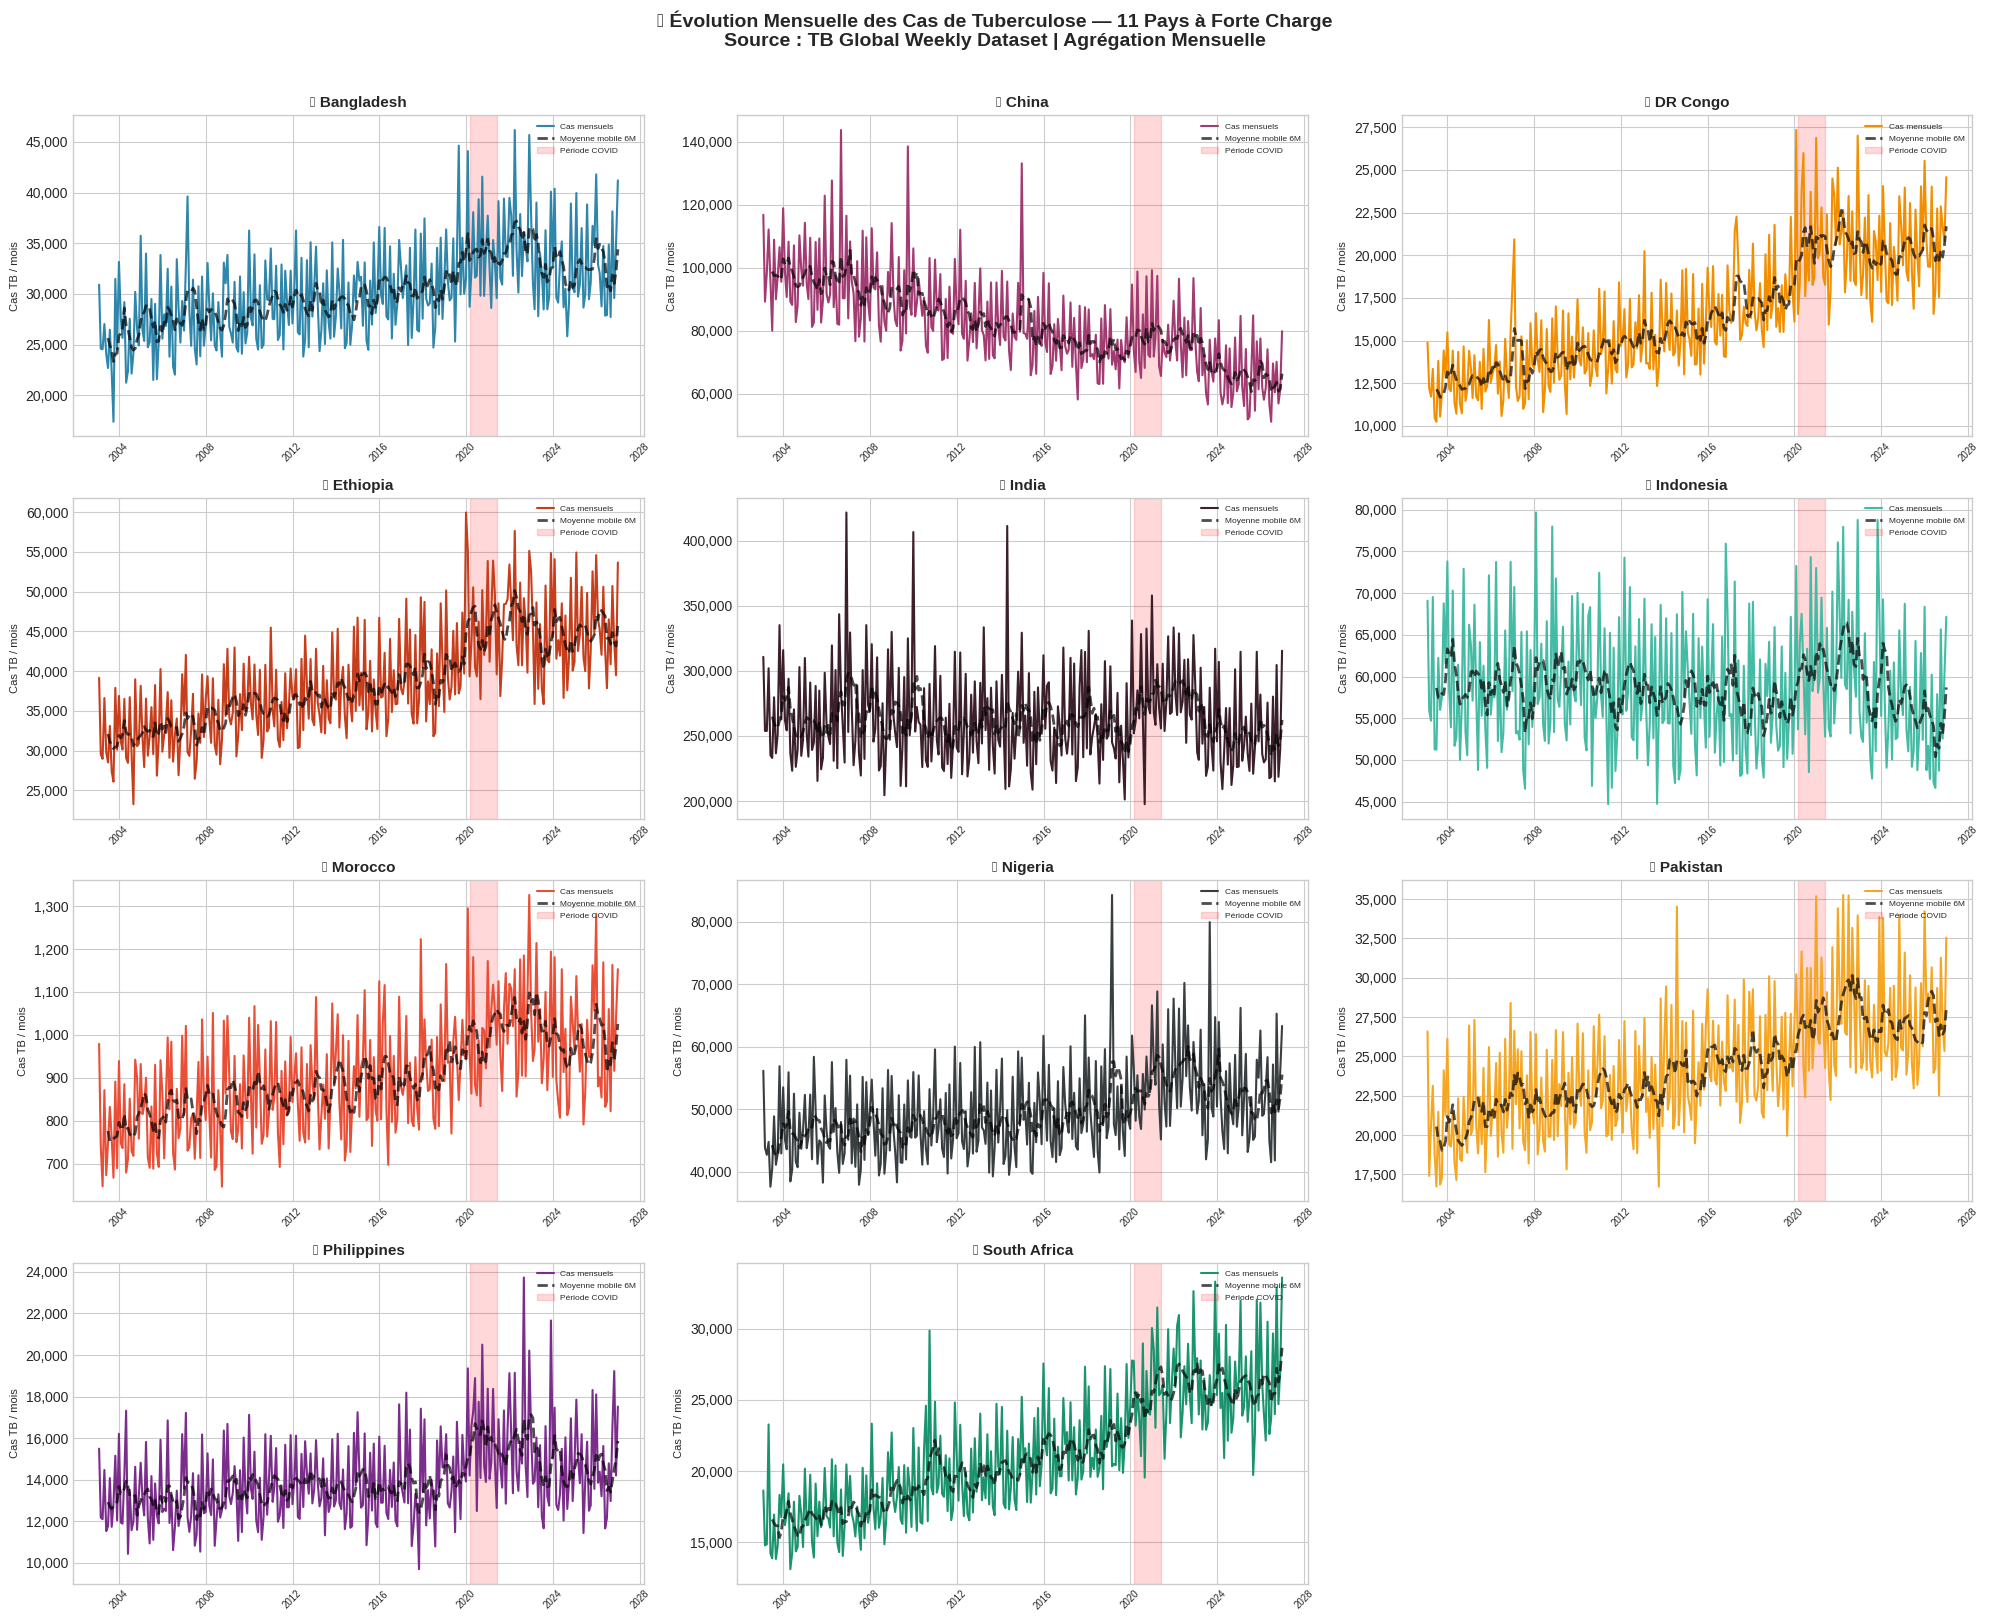

✅ Figure sauvegardée.


In [10]:
# ============================================================
# VIZ 1 : ÉVOLUTION MONDIALE DES CAS TB PAR PAYS
# ============================================================

fig, axes = plt.subplots(4, 3, figsize=(20, 16))
axes = axes.flatten()

for i, (country, grp) in enumerate(df_monthly.groupby('Country')):
    ax = axes[i]
    ax.plot(grp['Date'], grp['TB_Cases'], color=COLORS[i], linewidth=1.5, label='Cas mensuels')

    # Moyenne mobile 6 mois
    ax.plot(grp['Date'], grp['TB_Cases'].rolling(6).mean(),
            color='black', linewidth=2, linestyle='--', label='Moyenne mobile 6M', alpha=0.7)

    # Zone COVID
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
               alpha=0.15, color='red', label='Période COVID')

    ax.set_title(f'🌍 {country}', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Cas TB / mois', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.legend(fontsize=6, loc='upper right')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Masquer le dernier subplot
axes[-1].set_visible(False)

fig.suptitle('📊 Évolution Mensuelle des Cas de Tuberculose — 11 Pays à Forte Charge\n'
             'Source : TB Global Weekly Dataset | Agrégation Mensuelle',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig_evolution_tb.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée.")

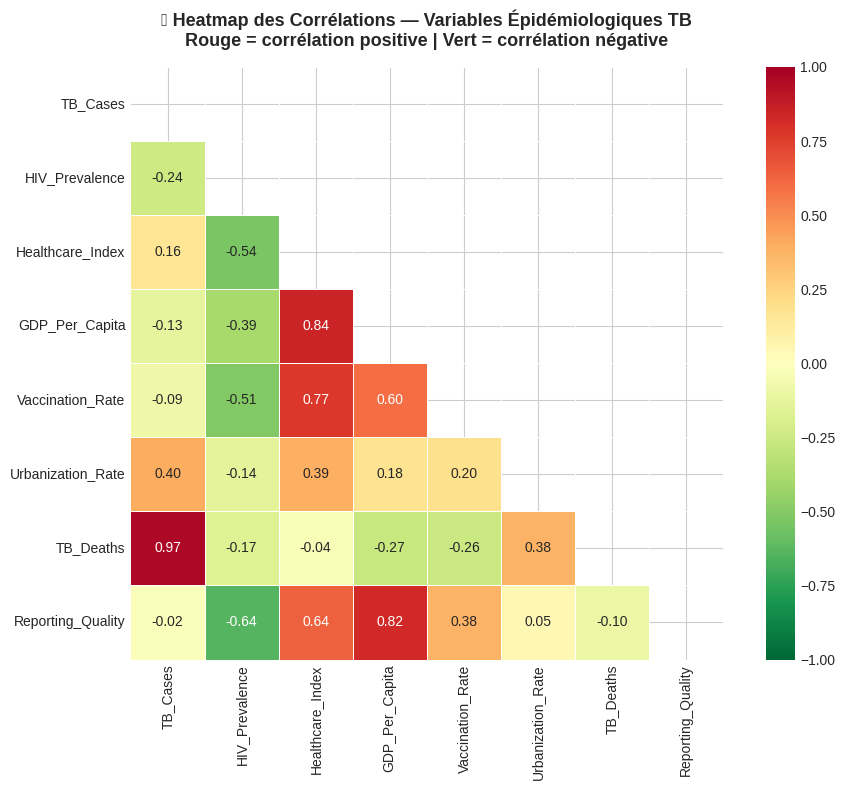


📌 Interprétation des corrélations :
  • HIV_Prevalence ↑  → TB_Cases ↑  : La co-infection VIH-TB est documentée scientifiquement
  • Healthcare_Index ↑ → TB_Cases ↓ : Meilleur système de santé = meilleure prévention
  • GDP_Per_Capita ↑  → TB_Cases ↓  : Richesse = meilleures conditions de vie
  • Vaccination_Rate ↑ → TB_Cases ↓ : Le BCG protège contre les formes graves


In [11]:
# ============================================================
# VIZ 2 : HEATMAP DES CORRÉLATIONS
# ============================================================

VARS_CORR = ['TB_Cases', 'HIV_Prevalence', 'Healthcare_Index',
             'GDP_Per_Capita', 'Vaccination_Rate', 'Urbanization_Rate',
             'TB_Deaths', 'Reporting_Quality']

corr_matrix = df_monthly[VARS_CORR].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, square=True, ax=ax, annot_kws={'size': 10},
            linewidths=0.5, vmin=-1, vmax=1)

ax.set_title('🔥 Heatmap des Corrélations — Variables Épidémiologiques TB\n'
             'Rouge = corrélation positive | Vert = corrélation négative',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig_heatmap_corr.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 Interprétation des corrélations :")
print("  • HIV_Prevalence ↑  → TB_Cases ↑  : La co-infection VIH-TB est documentée scientifiquement")
print("  • Healthcare_Index ↑ → TB_Cases ↓ : Meilleur système de santé = meilleure prévention")
print("  • GDP_Per_Capita ↑  → TB_Cases ↓  : Richesse = meilleures conditions de vie")
print("  • Vaccination_Rate ↑ → TB_Cases ↓ : Le BCG protège contre les formes graves")

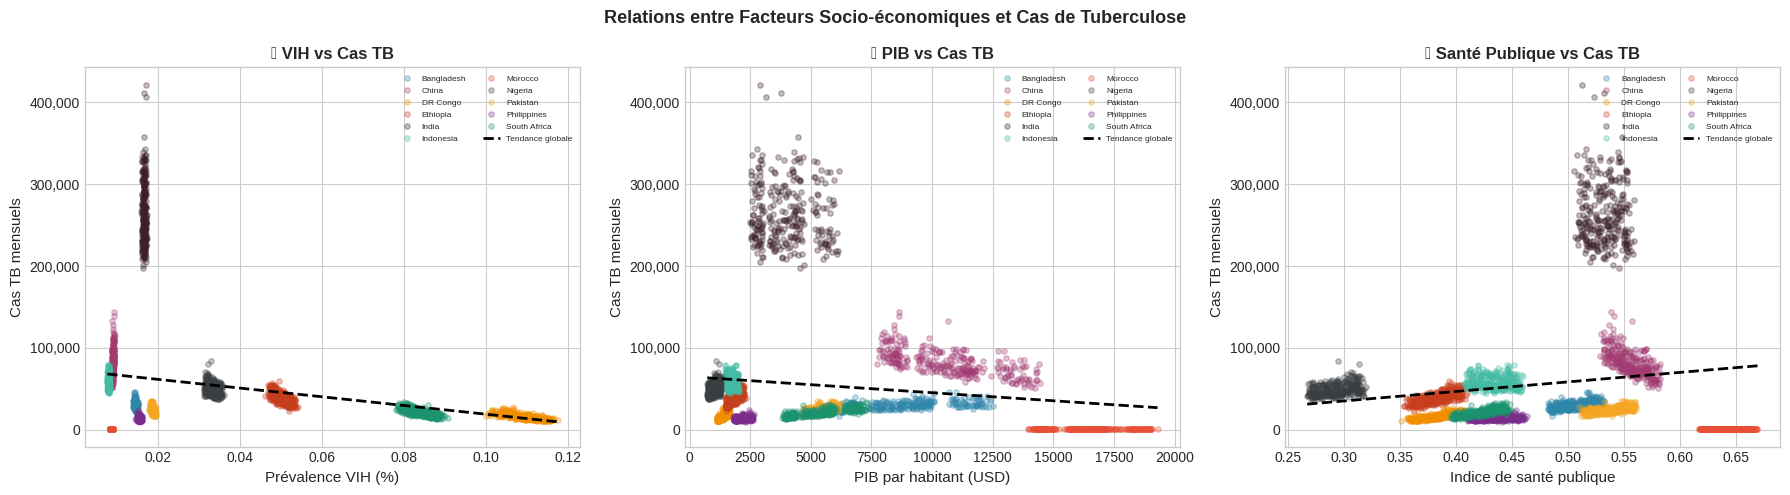

In [12]:
# ============================================================
# VIZ 3 : RELATIONS BIVARIÉES (HIV, GDP, Healthcare)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

vars_x = ['HIV_Prevalence', 'GDP_Per_Capita', 'Healthcare_Index']
labels_x = ['Prévalence VIH (%)', 'PIB par habitant (USD)', 'Indice de santé publique']
titres = ['VIH vs Cas TB', 'PIB vs Cas TB', 'Santé Publique vs Cas TB']

for ax, vx, lx, ti in zip(axes, vars_x, labels_x, titres):
    for j, (country, grp) in enumerate(df_monthly.groupby('Country')):
        ax.scatter(grp[vx], grp['TB_Cases'], alpha=0.3, s=15,
                   color=COLORS[j], label=country)

    # Droite de régression globale
    x_clean = df_monthly[vx].dropna()
    y_clean = df_monthly.loc[x_clean.index, 'TB_Cases']
    z = np.polyfit(x_clean, y_clean, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
    ax.plot(x_line, p(x_line), 'k--', linewidth=2, label='Tendance globale')

    ax.set_xlabel(lx, fontsize=11)
    ax.set_ylabel('Cas TB mensuels', fontsize=11)
    ax.set_title(f'📈 {ti}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=6, ncol=2, loc='upper right')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.suptitle('Relations entre Facteurs Socio-économiques et Cas de Tuberculose',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig_relations_bivariees.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ============================================================
# VIZ 4 : TOP PAYS À RISQUE (interactif Plotly)
# ============================================================

top_risk = df_monthly.groupby('Country').agg(
    Total_Cases=('TB_Cases', 'sum'),
    Moy_HIV=('HIV_Prevalence', 'mean'),
    Moy_Healthcare=('Healthcare_Index', 'mean')
).reset_index().sort_values('Total_Cases', ascending=False)

fig_risk = px.bar(
    top_risk, x='Country', y='Total_Cases',
    color='Moy_HIV', color_continuous_scale='Reds',
    title='🏴 Top Pays à Risque TB — Charge Totale & Prévalence VIH',
    labels={'Total_Cases': 'Cas TB Cumulés', 'Moy_HIV': 'Prévalence VIH moy. (%)'},
    text_auto='.2s'
)
fig_risk.update_layout(height=500, xaxis_tickangle=45)
fig_risk.show()
print("\n📌 L'Inde représente la charge TB la plus lourde au monde.")


📌 L'Inde représente la charge TB la plus lourde au monde.


## 🔬 Section 7 — Feature Engineering Avancé

### Pourquoi créer des variables dérivées ?
Les modèles ML ne capturent pas nativement la dépendance temporelle. Les **lags** et les **statistiques glissantes** encodent l'histoire de la série, permettant aux modèles de détecter des patterns complexes impossibles à capturer avec les variables brutes.


In [14]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

def create_features(grp):
    """Crée les features temporelles pour un pays donné."""
    grp = grp.copy().sort_values('Date')

    # Variables calendaires
    grp['month']   = grp['Date'].dt.month
    grp['quarter'] = grp['Date'].dt.quarter
    grp['year']    = grp['Date'].dt.year

    # Indicateurs saisonniers
    grp['sin_month'] = np.sin(2 * np.pi * grp['month'] / 12)
    grp['cos_month'] = np.cos(2 * np.pi * grp['month'] / 12)

    # Lags (mémoire temporelle)
    for lag in [1, 3, 6, 12]:
        grp[f'lag_{lag}'] = grp['TB_Cases'].shift(lag)

    # Statistiques glissantes
    grp['rolling_mean_3']  = grp['TB_Cases'].shift(1).rolling(3).mean()
    grp['rolling_mean_6']  = grp['TB_Cases'].shift(1).rolling(6).mean()
    grp['rolling_std_6']   = grp['TB_Cases'].shift(1).rolling(6).std()

    # Croissance mensuelle (taux de variation)
    grp['growth_rate'] = grp['TB_Cases'].pct_change()

    # Indicateur COVID
    grp['covid_flag'] = ((grp['Date'] >= '2020-03-01') &
                         (grp['Date'] <= '2021-12-31')).astype(int)

    return grp

# Application par pays
df_feat = df_monthly.groupby('Country', group_keys=False).apply(create_features)
df_feat = df_feat.reset_index(drop=True)

print(f"✅ Feature Engineering terminé")
print(f"   Colonnes créées : {df_feat.shape[1]} (vs {df_monthly.shape[1]} initiales)")
print(f"   Nouvelles features : {df_feat.shape[1] - df_monthly.shape[1]}")

# Features ML utilisées
FEATURES_ML = [
    'lag_1', 'lag_3', 'lag_6', 'lag_12',
    'rolling_mean_3', 'rolling_mean_6', 'rolling_std_6',
    'growth_rate', 'month', 'quarter', 'year',
    'sin_month', 'cos_month', 'covid_flag',
    'HIV_Prevalence', 'Healthcare_Index', 'GDP_Per_Capita',
    'Vaccination_Rate', 'Urbanization_Rate'
]

print(f"\n📊 Features ML utilisées ({len(FEATURES_ML)}) :")
print(' | '.join(FEATURES_ML))

✅ Feature Engineering terminé
   Colonnes créées : 26 (vs 12 initiales)
   Nouvelles features : 14

📊 Features ML utilisées (19) :
lag_1 | lag_3 | lag_6 | lag_12 | rolling_mean_3 | rolling_mean_6 | rolling_std_6 | growth_rate | month | quarter | year | sin_month | cos_month | covid_flag | HIV_Prevalence | Healthcare_Index | GDP_Per_Capita | Vaccination_Rate | Urbanization_Rate


## 📉 Section 8 — Analyse de Stationnarité

### Qu'est-ce que la stationnarité ?
Une série temporelle est **stationnaire** si ses propriétés statistiques (moyenne, variance, autocovariance) sont constantes dans le temps. Les modèles ARIMA nécessitent la stationnarité.

**Tests utilisés :**
- **ADF (Augmented Dickey-Fuller)** : H₀ = racine unitaire (non-stationnaire). P-value < 0.05 → rejeter H₀ → série stationnaire
- **KPSS** : H₀ = stationnarité. P-value > 0.05 → ne pas rejeter H₀ → série stationnaire


In [15]:
# ============================================================
# ANALYSE DE STATIONNARITÉ
# ============================================================

def test_stationnarite(serie, nom_pays):
    """Tests ADF et KPSS + rolling stats pour un pays."""
    serie = serie.dropna()
    resultats = {}

    # Test ADF
    try:
        adf_stat, adf_p, _, _, adf_crit, _ = adfuller(serie, autolag='AIC')
        resultats['ADF_stat'] = round(adf_stat, 4)
        resultats['ADF_p']    = round(adf_p, 4)
        resultats['ADF_result'] = '✅ Stationnaire' if adf_p < 0.05 else '❌ Non-stationnaire'
    except Exception as e:
        resultats['ADF_stat'] = None
        resultats['ADF_p'] = None
        resultats['ADF_result'] = f'Erreur: {e}'

    # Test KPSS
    try:
        kpss_stat, kpss_p, _, kpss_crit = kpss(serie, regression='c', nlags='auto')
        resultats['KPSS_stat']   = round(kpss_stat, 4)
        resultats['KPSS_p']      = round(kpss_p, 4)
        resultats['KPSS_result'] = '✅ Stationnaire' if kpss_p > 0.05 else '❌ Non-stationnaire'
    except Exception as e:
        resultats['KPSS_stat'] = None
        resultats['KPSS_p'] = None
        resultats['KPSS_result'] = f'Erreur: {e}'

    return resultats

# Analyse pour chaque pays
resultats_stat = []
for country, grp in df_monthly.groupby('Country'):
    serie = grp.set_index('Date')['TB_Cases']
    res = test_stationnarite(serie, country)
    res['Country'] = country
    resultats_stat.append(res)

df_stat = pd.DataFrame(resultats_stat)[['Country','ADF_stat','ADF_p','ADF_result','KPSS_stat','KPSS_p','KPSS_result']]
print("\n📊 Résultats des Tests de Stationnarité")
print("=" * 80)
print(df_stat.to_string(index=False))
print("\n📌 Interprétation :")
print("  • Si ADF p<0.05 ET KPSS p>0.05 → Série stationnaire → d=0")
print("  • Sinon → Différenciation nécessaire → d=1")


📊 Résultats des Tests de Stationnarité
     Country  ADF_stat  ADF_p         ADF_result  KPSS_stat  KPSS_p        KPSS_result
  Bangladesh   -1.4269 0.5693 ❌ Non-stationnaire     2.3056    0.01 ❌ Non-stationnaire
       China   -0.5467 0.8826 ❌ Non-stationnaire     2.5012    0.01 ❌ Non-stationnaire
    DR Congo   -0.3915 0.9115 ❌ Non-stationnaire     2.5928    0.01 ❌ Non-stationnaire
    Ethiopia   -0.8081 0.8167 ❌ Non-stationnaire     2.5254    0.01 ❌ Non-stationnaire
       India   -2.9632 0.0385     ✅ Stationnaire     0.1318    0.10     ✅ Stationnaire
   Indonesia   -2.3342 0.1612 ❌ Non-stationnaire     0.2055    0.10     ✅ Stationnaire
     Morocco   -1.4146 0.5752 ❌ Non-stationnaire     2.5755    0.01 ❌ Non-stationnaire
     Nigeria   -1.3613 0.6007 ❌ Non-stationnaire     2.2031    0.01 ❌ Non-stationnaire
    Pakistan   -1.0066 0.7509 ❌ Non-stationnaire     2.4602    0.01 ❌ Non-stationnaire
 Philippines   -1.6005 0.4833 ❌ Non-stationnaire     1.8371    0.01 ❌ Non-stationnaire
Sou

/tmp/ipykernel_9651/1007300073.py:23: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.


/tmp/ipykernel_9651/1007300073.py:23: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.


/tmp/ipykernel_9651/1007300073.py:23: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.


/tmp/ipykernel_9651/1007300073.py:23: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.


/tmp/ipykernel_9651/1007300073.py:23: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is gr

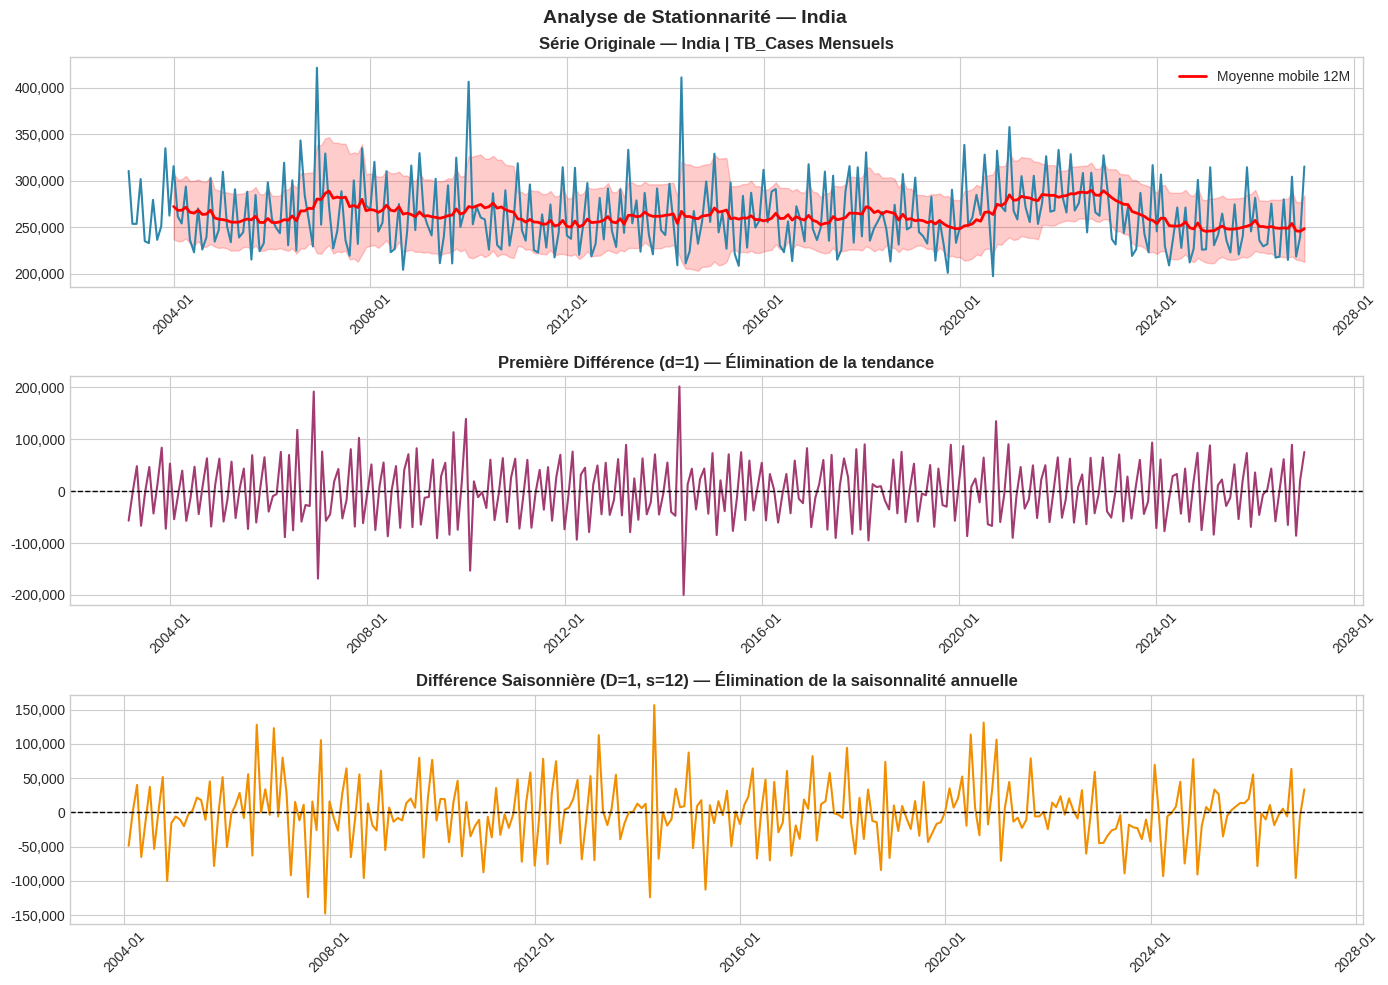

In [16]:
# ============================================================
# ROLLING MEAN & STD — VISUALISATION STATIONNARITÉ
# ============================================================

# Exemple sur l'Inde
country_ex = 'India'
serie_ex = df_monthly[df_monthly['Country'] == country_ex].set_index('Date')['TB_Cases']

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Série originale
axes[0].plot(serie_ex.index, serie_ex.values, color='#2E86AB', linewidth=1.5)
axes[0].plot(serie_ex.rolling(12).mean(), color='red', linewidth=2, label='Moyenne mobile 12M')
axes[0].fill_between(serie_ex.index, serie_ex.rolling(12).mean() - serie_ex.rolling(12).std(),
                     serie_ex.rolling(12).mean() + serie_ex.rolling(12).std(),
                     alpha=0.2, color='red')
axes[0].set_title(f'Série Originale — {country_ex} | TB_Cases Mensuels', fontweight='bold')
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Première différence
serie_diff1 = serie_ex.diff().dropna()
axes[1].plot(serie_diff1.index, serie_diff1.values, color='#A23B72', linewidth=1.5)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Première Différence (d=1) — Élimination de la tendance', fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Différence saisonnière
serie_diff_s = serie_ex.diff(12).dropna()
axes[2].plot(serie_diff_s.index, serie_diff_s.values, color='#F18F01', linewidth=1.5)
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[2].set_title('Différence Saisonnière (D=1, s=12) — Élimination de la saisonnalité annuelle', fontweight='bold')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(f'Analyse de Stationnarité — {country_ex}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig_stationnarite.png', dpi=150, bbox_inches='tight')
plt.show()

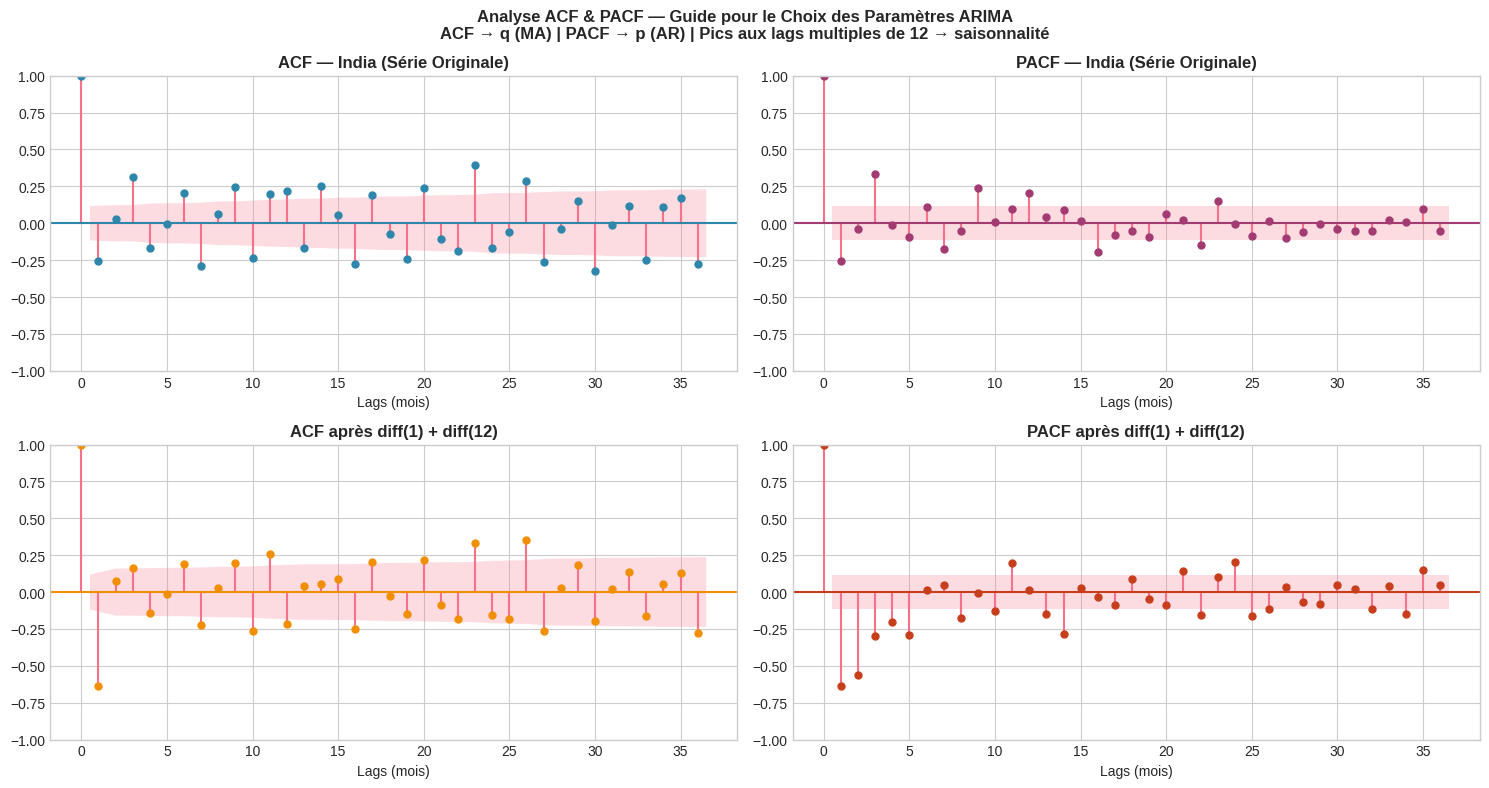


📌 Guide de lecture :
  • ACF : Décroissance lente → tendance → différencier (d=1)
  • ACF : Pics aux lags 12, 24... → saisonnalité annuelle (s=12)
  • PACF : Coupure après lag p → paramètre AR = p
  • ACF : Coupure après lag q  → paramètre MA = q


In [17]:
# ============================================================
# ACF & PACF — CHOIX DES PARAMÈTRES p, d, q
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# ACF & PACF série originale
plot_acf(serie_ex, lags=36, ax=axes[0,0], color='#2E86AB')
axes[0,0].set_title(f'ACF — {country_ex} (Série Originale)', fontweight='bold')
axes[0,0].set_xlabel('Lags (mois)')

plot_pacf(serie_ex, lags=36, ax=axes[0,1], method='ywm', color='#A23B72')
axes[0,1].set_title(f'PACF — {country_ex} (Série Originale)', fontweight='bold')
axes[0,1].set_xlabel('Lags (mois)')

# ACF & PACF après différenciation
serie_diff12 = serie_ex.diff(1).diff(12).dropna()
plot_acf(serie_diff12, lags=36, ax=axes[1,0], color='#F18F01')
axes[1,0].set_title('ACF après diff(1) + diff(12)', fontweight='bold')
axes[1,0].set_xlabel('Lags (mois)')

plot_pacf(serie_diff12, lags=36, ax=axes[1,1], method='ywm', color='#C73E1D')
axes[1,1].set_title('PACF après diff(1) + diff(12)', fontweight='bold')
axes[1,1].set_xlabel('Lags (mois)')

plt.suptitle('Analyse ACF & PACF — Guide pour le Choix des Paramètres ARIMA\n'
             'ACF → q (MA) | PACF → p (AR) | Pics aux lags multiples de 12 → saisonnalité',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 Guide de lecture :")
print("  • ACF : Décroissance lente → tendance → différencier (d=1)")
print("  • ACF : Pics aux lags 12, 24... → saisonnalité annuelle (s=12)")
print("  • PACF : Coupure après lag p → paramètre AR = p")
print("  • ACF : Coupure après lag q  → paramètre MA = q")

## 🤖 Section 9 — Modélisation & Comparaison des Modèles

### 9.1 Fonctions utilitaires

**Modèles comparés :**
| Modèle | Type | Avantages |
|--------|------|----------|
| ARIMA  | Statistique | Interprétable, baseline robuste |
| SARIMA | Statistique | Capture la saisonnalité annuelle |
| SARIMAX| Statistique | Variables exogènes (VIH, PIB...) |
| XGBoost| ML Boosting | Non-linéarités, interactions complexes |
| LightGBM| ML Boosting | Ultra-rapide, efficace sur données bruitées |

### Pourquoi le Boosting pour l'épidémiologie ?
Les données épidémiologiques sont **non-linéaires**, **bruitées** et **multi-factorielles**. XGBoost et LightGBM capturent ces interactions complexes sans hypothèses de linéarité, tout en gérant naturellement les valeurs aberrantes grâce à la descente de gradient robuste.


In [18]:
# ============================================================
# FONCTIONS UTILITAIRES
# ============================================================

def calcul_metriques(y_true, y_pred, model_name='', aic=None, bic=None):
    """Calcule RMSE, MAE, R² (et optionnellement MAPE)."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    # MAPE optionnel
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.any() else None

    return {'RMSE': round(rmse, 2), 'MAE': round(mae, 2),
            'R2': round(r2, 4), 'MAPE': round(mape, 2) if mape else None,
            'AIC': round(aic, 2) if aic else None,
            'BIC': round(bic, 2) if bic else None}


def split_train_test(serie, ratio=0.8):
    """Split chronologique (jamais aléatoire)."""
    n = len(serie)
    split = int(n * ratio)
    return serie[:split], serie[split:]


def sauvegarder_modele(modele, chemin):
    """Sauvegarde un modèle au format .pkl."""
    try:
        with open(chemin, 'wb') as f:
            pickle.dump(modele, f)
        return True
    except Exception as e:
        print(f'  ⚠️ Sauvegarde échouée : {e}')
        return False


# Dictionnaire global pour stocker toutes les métriques
ALL_METRICS = []
ALL_FORECASTS = {}
ALL_MODELS = {}

print("✅ Fonctions utilitaires définies.")

✅ Fonctions utilitaires définies.


### 9.2 Modèles Statistiques (ARIMA, SARIMA, SARIMAX)


In [19]:
# ============================================================
# MODÈLES STATISTIQUES : ARIMA, SARIMA, SARIMAX
# ============================================================

# Paramètres ARIMA par défaut (adaptés aux données TB mensuelles)
ARIMA_ORDER   = (1, 1, 1)
SARIMA_ORDER  = (1, 1, 1)
SARIMA_S      = (1, 1, 1, 12)  # s=12 pour saisonnalité annuelle

VARS_EXOG = ['HIV_Prevalence', 'Healthcare_Index', 'GDP_Per_Capita',
             'Vaccination_Rate', 'Urbanization_Rate']

print("🔄 Entraînement des modèles statistiques par pays...")
print(f"   Paramètres ARIMA  : {ARIMA_ORDER}")
print(f"   Paramètres SARIMA : (1,1,1)×(1,1,1,12)")
print(f"   Variables exogènes: {VARS_EXOG}")
print()

for country in tqdm(PAYS_CIBLES, desc='Pays'):
    grp = df_monthly[df_monthly['Country'] == country].copy()
    grp = grp.sort_values('Date').set_index('Date')
    grp.index.freq = 'M'

    serie = grp['TB_Cases'].asfreq('M')
    exog  = grp[VARS_EXOG].asfreq('M')

    # Split chronologique 80/20
    n_train = int(len(serie) * 0.8)
    train, test = serie[:n_train], serie[n_train:]
    exog_train, exog_test = exog[:n_train], exog[n_train:]

    # ---- ARIMA ----
    try:
        arima_mod = ARIMA(train, order=ARIMA_ORDER).fit()
        pred_arima = arima_mod.forecast(steps=len(test))
        m = calcul_metriques(test, pred_arima, 'ARIMA',
                             aic=arima_mod.aic, bic=arima_mod.bic)
        m.update({'Country': country, 'Model': 'ARIMA'})
        ALL_METRICS.append(m)
        sauvegarder_modele(arima_mod, OUTPUT_DIR + f'models/ARIMA_{country}.pkl')
        ALL_MODELS[f'ARIMA_{country}'] = arima_mod
    except Exception as e:
        print(f'  ⚠️ ARIMA {country} : {e}')

    # ---- SARIMA ----
    try:
        sarima_mod = SARIMAX(train, order=SARIMA_ORDER,
                             seasonal_order=SARIMA_S,
                             enforce_stationarity=False,
                             enforce_invertibility=False).fit(disp=False)
        pred_sarima = sarima_mod.forecast(steps=len(test))
        m = calcul_metriques(test, pred_sarima, 'SARIMA',
                             aic=sarima_mod.aic, bic=sarima_mod.bic)
        m.update({'Country': country, 'Model': 'SARIMA'})
        ALL_METRICS.append(m)
        sauvegarder_modele(sarima_mod, OUTPUT_DIR + f'models/SARIMA_{country}.pkl')
        ALL_MODELS[f'SARIMA_{country}'] = sarima_mod
    except Exception as e:
        print(f'  ⚠️ SARIMA {country} : {e}')

    # ---- SARIMAX ----
    try:
        sarimax_mod = SARIMAX(train, exog=exog_train, order=SARIMA_ORDER,
                              seasonal_order=SARIMA_S,
                              enforce_stationarity=False,
                              enforce_invertibility=False).fit(disp=False)
        pred_sarimax = sarimax_mod.forecast(steps=len(test), exog=exog_test)
        m = calcul_metriques(test, pred_sarimax, 'SARIMAX',
                             aic=sarimax_mod.aic, bic=sarimax_mod.bic)
        m.update({'Country': country, 'Model': 'SARIMAX'})
        ALL_METRICS.append(m)
        sauvegarder_modele(sarimax_mod, OUTPUT_DIR + f'models/SARIMAX_{country}.pkl')
        ALL_MODELS[f'SARIMAX_{country}'] = sarimax_mod
    except Exception as e:
        print(f'  ⚠️ SARIMAX {country} : {e}')

    gc.collect()

print("\n✅ Modèles statistiques entraînés et sauvegardés.")

🔄 Entraînement des modèles statistiques par pays...
   Paramètres ARIMA  : (1, 1, 1)
   Paramètres SARIMA : (1,1,1)×(1,1,1,12)
   Variables exogènes: ['HIV_Prevalence', 'Healthcare_Index', 'GDP_Per_Capita', 'Vaccination_Rate', 'Urbanization_Rate']



Pays:  27%|██▋       | 3/11 [00:21<00:59,  7.48s/it]/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

Pays:  73%|███████▎  | 8/11 [01:00<00:23,  7.73s/it]/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

Pays: 100%|██████████| 11/11 [01:28<00:00,  8.08s/it]


✅ Modèles statistiques entraînés et sauvegardés.


### 9.3 Modèles Machine Learning (XGBoost & LightGBM)


In [20]:
# ============================================================
# MODÈLES ML : XGBOOST & LIGHTGBM
# ============================================================

print("🤖 Entraînement des modèles ML par pays...")

for country in tqdm(PAYS_CIBLES, desc='Pays ML'):
    grp = df_feat[df_feat['Country'] == country].copy()
    grp = grp.sort_values('Date').dropna(subset=FEATURES_ML + ['TB_Cases'])

    if len(grp) < 20:
        print(f'  ⚠️ {country} : données insuffisantes ({len(grp)} obs)')
        continue

    X = grp[FEATURES_ML]
    y = grp['TB_Cases']

    # Split chronologique 80/20
    n_train = int(len(grp) * 0.8)
    X_train, X_test = X.iloc[:n_train], X.iloc[n_train:]
    y_train, y_test = y.iloc[:n_train], y.iloc[n_train:]

    # ---- XGBOOST ----
    try:
        xgb_mod = xgb.XGBRegressor(
            n_estimators=500, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
            reg_alpha=0.1, reg_lambda=1.0, random_state=42,
            early_stopping_rounds=30, eval_metric='rmse', verbosity=0
        )
        xgb_mod.fit(X_train, y_train,
                    eval_set=[(X_test, y_test)], verbose=False)
        pred_xgb = xgb_mod.predict(X_test)
        m = calcul_metriques(y_test, pred_xgb, 'XGBoost')
        m.update({'Country': country, 'Model': 'XGBoost', 'AIC': None, 'BIC': None})
        ALL_METRICS.append(m)
        sauvegarder_modele(xgb_mod, OUTPUT_DIR + f'models/XGBoost_{country}.pkl')
        ALL_MODELS[f'XGBoost_{country}'] = xgb_mod
    except Exception as e:
        print(f'  ⚠️ XGBoost {country} : {e}')

    # ---- LIGHTGBM ----
    try:
        lgb_train = lgb.Dataset(X_train, label=y_train)
        lgb_val   = lgb.Dataset(X_test, label=y_test, reference=lgb_train)

        params = {
            'objective': 'regression', 'metric': 'rmse',
            'learning_rate': 0.05, 'num_leaves': 31,
            'max_depth': 4, 'min_data_in_leaf': 5,
            'feature_fraction': 0.8, 'bagging_fraction': 0.8,
            'bagging_freq': 5, 'lambda_l1': 0.1, 'lambda_l2': 1.0,
            'verbose': -1, 'random_state': 42
        }
        lgb_mod = lgb.train(
            params, lgb_train, num_boost_round=500,
            valid_sets=[lgb_val],
            callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)]
        )
        pred_lgb = lgb_mod.predict(X_test)
        m = calcul_metriques(y_test, pred_lgb, 'LightGBM')
        m.update({'Country': country, 'Model': 'LightGBM', 'AIC': None, 'BIC': None})
        ALL_METRICS.append(m)
        sauvegarder_modele(lgb_mod, OUTPUT_DIR + f'models/LightGBM_{country}.pkl')
        ALL_MODELS[f'LightGBM_{country}'] = lgb_mod
    except Exception as e:
        print(f'  ⚠️ LightGBM {country} : {e}')

    gc.collect()

print("\n✅ Modèles ML entraînés et sauvegardés.")

🤖 Entraînement des modèles ML par pays...


Pays ML: 100%|██████████| 11/11 [00:22<00:00,  2.06s/it]


✅ Modèles ML entraînés et sauvegardés.


## 📊 Section 10 — Comparaison des Modèles


In [21]:
# ============================================================
# TABLEAU GLOBAL DES MÉTRIQUES
# ============================================================

df_metrics = pd.DataFrame(ALL_METRICS)
df_metrics = df_metrics[['Country','Model','RMSE','MAE','R2','AIC','BIC','MAPE']]
df_metrics = df_metrics.sort_values(['Country','R2'], ascending=[True, False])

print("\n📊 TABLEAU GLOBAL DES PERFORMANCES")
print("=" * 90)
print(df_metrics.to_string(index=False))

# Meilleur modèle par pays
best_models = df_metrics.loc[df_metrics.groupby('Country')['R2'].idxmax()]
print("\n\n🏆 MEILLEUR MODÈLE PAR PAYS")
print("=" * 60)
for _, row in best_models.iterrows():
    print(f"  {row['Country']:<15} → {row['Model']:<10} | R²={row['R2']:.4f} | RMSE={row['RMSE']:,.0f}")

# Export Excel
df_metrics.to_excel(OUTPUT_DIR + 'global_metrics.xlsx', index=False)
print("\n✅ global_metrics.xlsx exporté.")


📊 TABLEAU GLOBAL DES PERFORMANCES
     Country    Model     RMSE      MAE      R2     AIC     BIC  MAPE
  Bangladesh  XGBoost  2711.01  2158.61  0.6326     NaN     NaN  6.71
  Bangladesh LightGBM  2780.09  2272.09  0.6137     NaN     NaN  7.30
  Bangladesh    ARIMA  4808.07  4101.73 -0.0407 4459.44 4469.74 12.60
  Bangladesh   SARIMA  5491.49  4497.74 -0.3576 3991.27 4007.83 14.36
  Bangladesh  SARIMAX  6898.08  5642.96 -1.1421 4053.23 4086.36 17.69
       China LightGBM  8521.52  7319.34  0.3230     NaN     NaN 11.76
       China  XGBoost  8881.87  7642.91  0.2645     NaN     NaN 12.23
       China   SARIMA 11520.05  9938.09 -0.1201 4477.50 4494.07 15.33
       China    ARIMA 13838.63 11646.34 -0.6163 4989.11 4999.41 18.73
       China  SARIMAX 26105.39 23784.54 -4.7519 4469.58 4502.72 37.87
    DR Congo LightGBM  1064.68   857.57  0.8322     NaN     NaN  4.21
    DR Congo  XGBoost  1184.43   967.98  0.7923     NaN     NaN  4.73
    DR Congo    ARIMA  2711.65  2360.29 -0.0936 4213.22

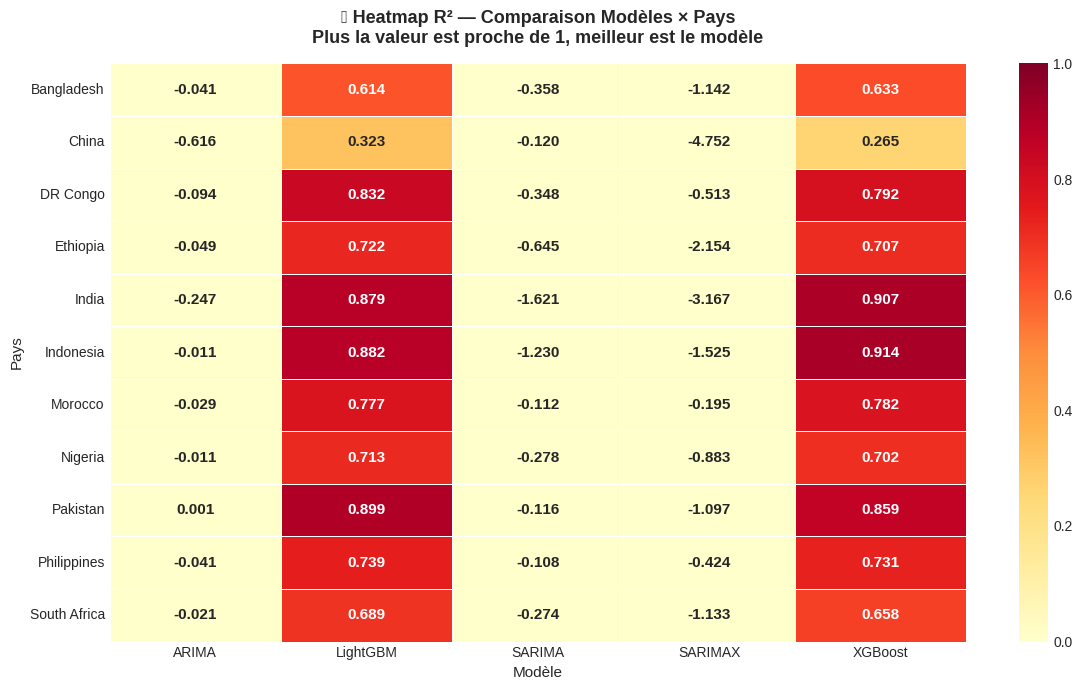

In [22]:
# ============================================================
# HEATMAP DES PERFORMANCES R² PAR PAYS ET MODÈLE
# ============================================================

pivot_r2 = df_metrics.pivot(index='Country', columns='Model', values='R2')

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(pivot_r2, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=ax, linewidths=0.5, vmin=0, vmax=1,
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('🏆 Heatmap R² — Comparaison Modèles × Pays\n'
             'Plus la valeur est proche de 1, meilleur est le modèle',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Modèle', fontsize=11)
ax.set_ylabel('Pays', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig_heatmap_r2.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ============================================================
# BARPLOT COMPARATIF — R² PAR MODÈLE
# ============================================================

fig = px.box(
    df_metrics, x='Model', y='R2',
    color='Model', points='all',
    title='📦 Distribution du R² par Modèle (tous pays confondus)',
    labels={'R2': 'R² (coefficient de détermination)', 'Model': 'Modèle'},
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.add_hline(y=0.8, line_dash='dash', line_color='red',
              annotation_text='Seuil objectif R²=0.8')
fig.update_layout(height=450, showlegend=False)
fig.show()

## 🔮 Section 11 — Forecast Futur (12 et 24 Mois)


In [24]:
# ============================================================
# GÉNÉRATION DES FORECASTS FUTURS
# ============================================================

HORIZONS = [12, 24]  # Mois à prédire
forecast_rows = []

print("🔮 Génération des prévisions futures...")

for country in tqdm(PAYS_CIBLES, desc='Forecast pays'):
    grp = df_monthly[df_monthly['Country'] == country].copy()
    grp = grp.sort_values('Date').set_index('Date')
    grp.index.freq = 'M'

    serie = grp['TB_Cases'].asfreq('M')
    exog  = grp[VARS_EXOG].asfreq('M')
    last_date = serie.index[-1]

    for horizon in HORIZONS:
        future_dates = pd.date_range(last_date + pd.offsets.MonthEnd(1),
                                     periods=horizon, freq='M')

        # Extrapolation variables exogènes (dernières valeurs moyennes)
        exog_future = pd.DataFrame(
            {col: [exog[col].tail(12).mean()] * horizon for col in VARS_EXOG},
            index=future_dates
        )

        # SARIMA forecast
        try:
            sarima_key = f'SARIMA_{country}'
            if sarima_key in ALL_MODELS:
                sarima_mod = ALL_MODELS[sarima_key]
                fc = sarima_mod.get_forecast(steps=horizon)
                fc_mean = fc.predicted_mean
                fc_ci   = fc.conf_int(alpha=0.05)

                for i, d in enumerate(future_dates):
                    forecast_rows.append({
                        'Country': country, 'Model': 'SARIMA',
                        'Date': d, 'Horizon': horizon,
                        'Forecast': max(0, fc_mean.iloc[i]),
                        'Lower_CI': max(0, fc_ci.iloc[i, 0]),
                        'Upper_CI': max(0, fc_ci.iloc[i, 1])
                    })
        except Exception as e:
            pass

    ALL_FORECASTS[country] = forecast_rows
    gc.collect()

df_forecasts = pd.DataFrame(forecast_rows)
df_forecasts.to_excel(OUTPUT_DIR + 'global_forecasts.xlsx', index=False)
print(f"\n✅ {len(df_forecasts)} prévisions générées et exportées.")

🔮 Génération des prévisions futures...


Forecast pays: 100%|██████████| 11/11 [00:03<00:00,  3.09it/s]



✅ 396 prévisions générées et exportées.


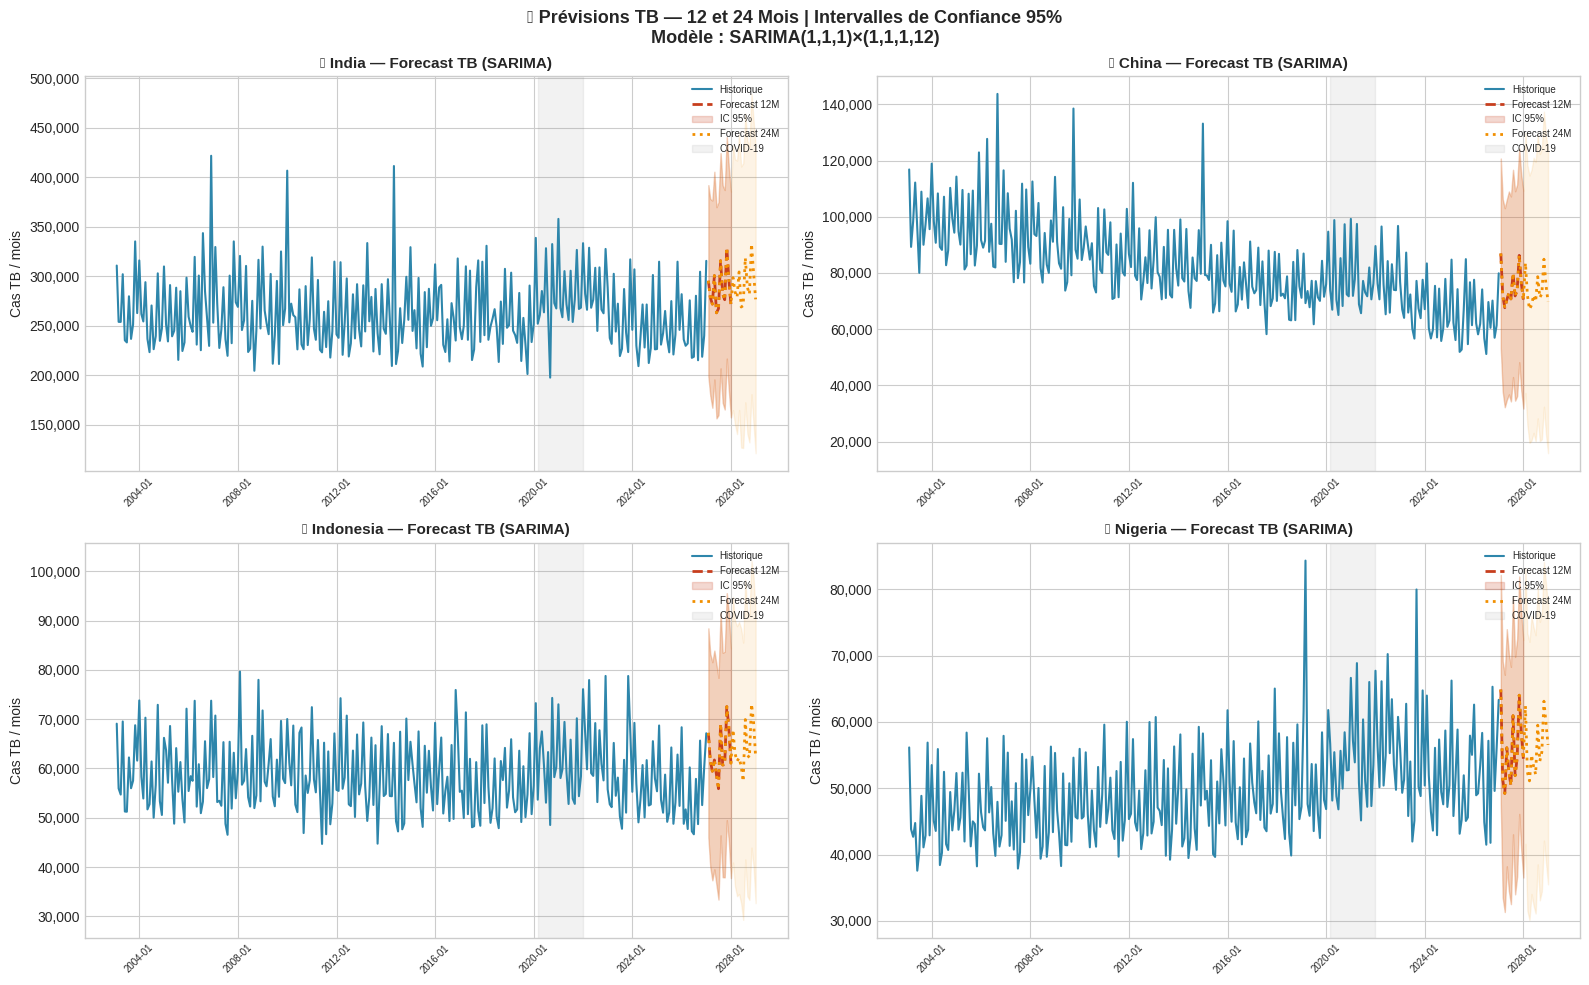

In [25]:
# ============================================================
# VISUALISATION FORECAST 12 & 24 MOIS — TOP 4 PAYS
# ============================================================

top4 = ['India', 'China', 'Indonesia', 'Nigeria']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, country in enumerate(top4):
    ax = axes[i]

    # Historique
    hist = df_monthly[df_monthly['Country'] == country].sort_values('Date')
    ax.plot(hist['Date'], hist['TB_Cases'], color='#2E86AB', linewidth=1.5, label='Historique')

    # Forecast 12M
    fc12 = df_forecasts[(df_forecasts['Country'] == country) &
                        (df_forecasts['Horizon'] == 12)]
    if not fc12.empty:
        ax.plot(fc12['Date'], fc12['Forecast'], color='#C73E1D', linewidth=2,
                linestyle='--', label='Forecast 12M')
        ax.fill_between(fc12['Date'], fc12['Lower_CI'], fc12['Upper_CI'],
                        alpha=0.2, color='#C73E1D', label='IC 95%')

    # Forecast 24M
    fc24 = df_forecasts[(df_forecasts['Country'] == country) &
                        (df_forecasts['Horizon'] == 24)]
    if not fc24.empty:
        ax.plot(fc24['Date'], fc24['Forecast'], color='#F18F01', linewidth=2,
                linestyle=':', label='Forecast 24M')
        ax.fill_between(fc24['Date'], fc24['Lower_CI'], fc24['Upper_CI'],
                        alpha=0.1, color='#F18F01')

    # Zone COVID
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
               alpha=0.1, color='gray', label='COVID-19')

    ax.set_title(f'🔮 {country} — Forecast TB (SARIMA)', fontweight='bold', fontsize=11)
    ax.set_ylabel('Cas TB / mois')
    ax.legend(fontsize=7, loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.suptitle('📈 Prévisions TB — 12 et 24 Mois | Intervalles de Confiance 95%\n'
             'Modèle : SARIMA(1,1,1)×(1,1,1,12)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()

## 🚨 Section 12 — Détection d'Anomalies

### Méthodes utilisées
- **Z-score** : Anomalie si |z| > 2.5 (écart-type)
- **IQR** : Anomalie si valeur hors [Q1 - 1.5×IQR, Q3 + 1.5×IQR]
- Les deux méthodes combinées permettent de détecter anomalies COVID, sous-déclarations et spikes épidémiques


In [26]:
# ============================================================
# DÉTECTION D'ANOMALIES (Z-SCORE + IQR)
# ============================================================

def detecter_anomalies(grp, seuil_z=2.5):
    """Détecte les anomalies par Z-score et IQR."""
    grp = grp.copy()
    serie = grp['TB_Cases']

    # Z-score
    z_scores = np.abs(stats.zscore(serie.dropna()))
    grp['z_score'] = np.nan
    grp.loc[serie.dropna().index, 'z_score'] = z_scores
    grp['anomalie_zscore'] = grp['z_score'] > seuil_z

    # IQR
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    grp['anomalie_iqr'] = (serie < Q1 - 1.5*IQR) | (serie > Q3 + 1.5*IQR)

    # Anomalie combinée
    grp['anomalie'] = grp['anomalie_zscore'] | grp['anomalie_iqr']

    # Type d'anomalie
    covid_mask = (grp['Date'] >= '2020-03-01') & (grp['Date'] <= '2021-12-31')
    grp['type_anomalie'] = 'Normal'
    grp.loc[grp['anomalie'] & covid_mask, 'type_anomalie']  = 'COVID-19'
    grp.loc[grp['anomalie'] & ~covid_mask & (serie > Q3 + 1.5*IQR), 'type_anomalie'] = 'Spike épidémique'
    grp.loc[grp['anomalie'] & ~covid_mask & (serie < Q1 - 1.5*IQR), 'type_anomalie'] = 'Sous-déclaration'

    return grp

anomalies_list = []
df_monthly_anom = []

for country, grp in df_monthly.groupby('Country'):
    grp_anom = detecter_anomalies(grp.reset_index(drop=True))
    df_monthly_anom.append(grp_anom)
    anoms = grp_anom[grp_anom['anomalie']]
    anomalies_list.append(anoms)

df_monthly_anom = pd.concat(df_monthly_anom, ignore_index=True)
df_anomalies = pd.concat(anomalies_list, ignore_index=True)

print(f"🚨 Total anomalies détectées : {len(df_anomalies)}")
print(f"   Répartition par type :")
print(df_anomalies['type_anomalie'].value_counts().to_string())

# Export
df_anomalies[['Country','Date','TB_Cases','z_score','type_anomalie']].to_excel(
    OUTPUT_DIR + 'anomalies.xlsx', index=False)
print("\n✅ anomalies.xlsx exporté.")

🚨 Total anomalies détectées : 45
   Répartition par type :
type_anomalie
Spike épidémique    22
Normal              16
COVID-19             7

✅ anomalies.xlsx exporté.


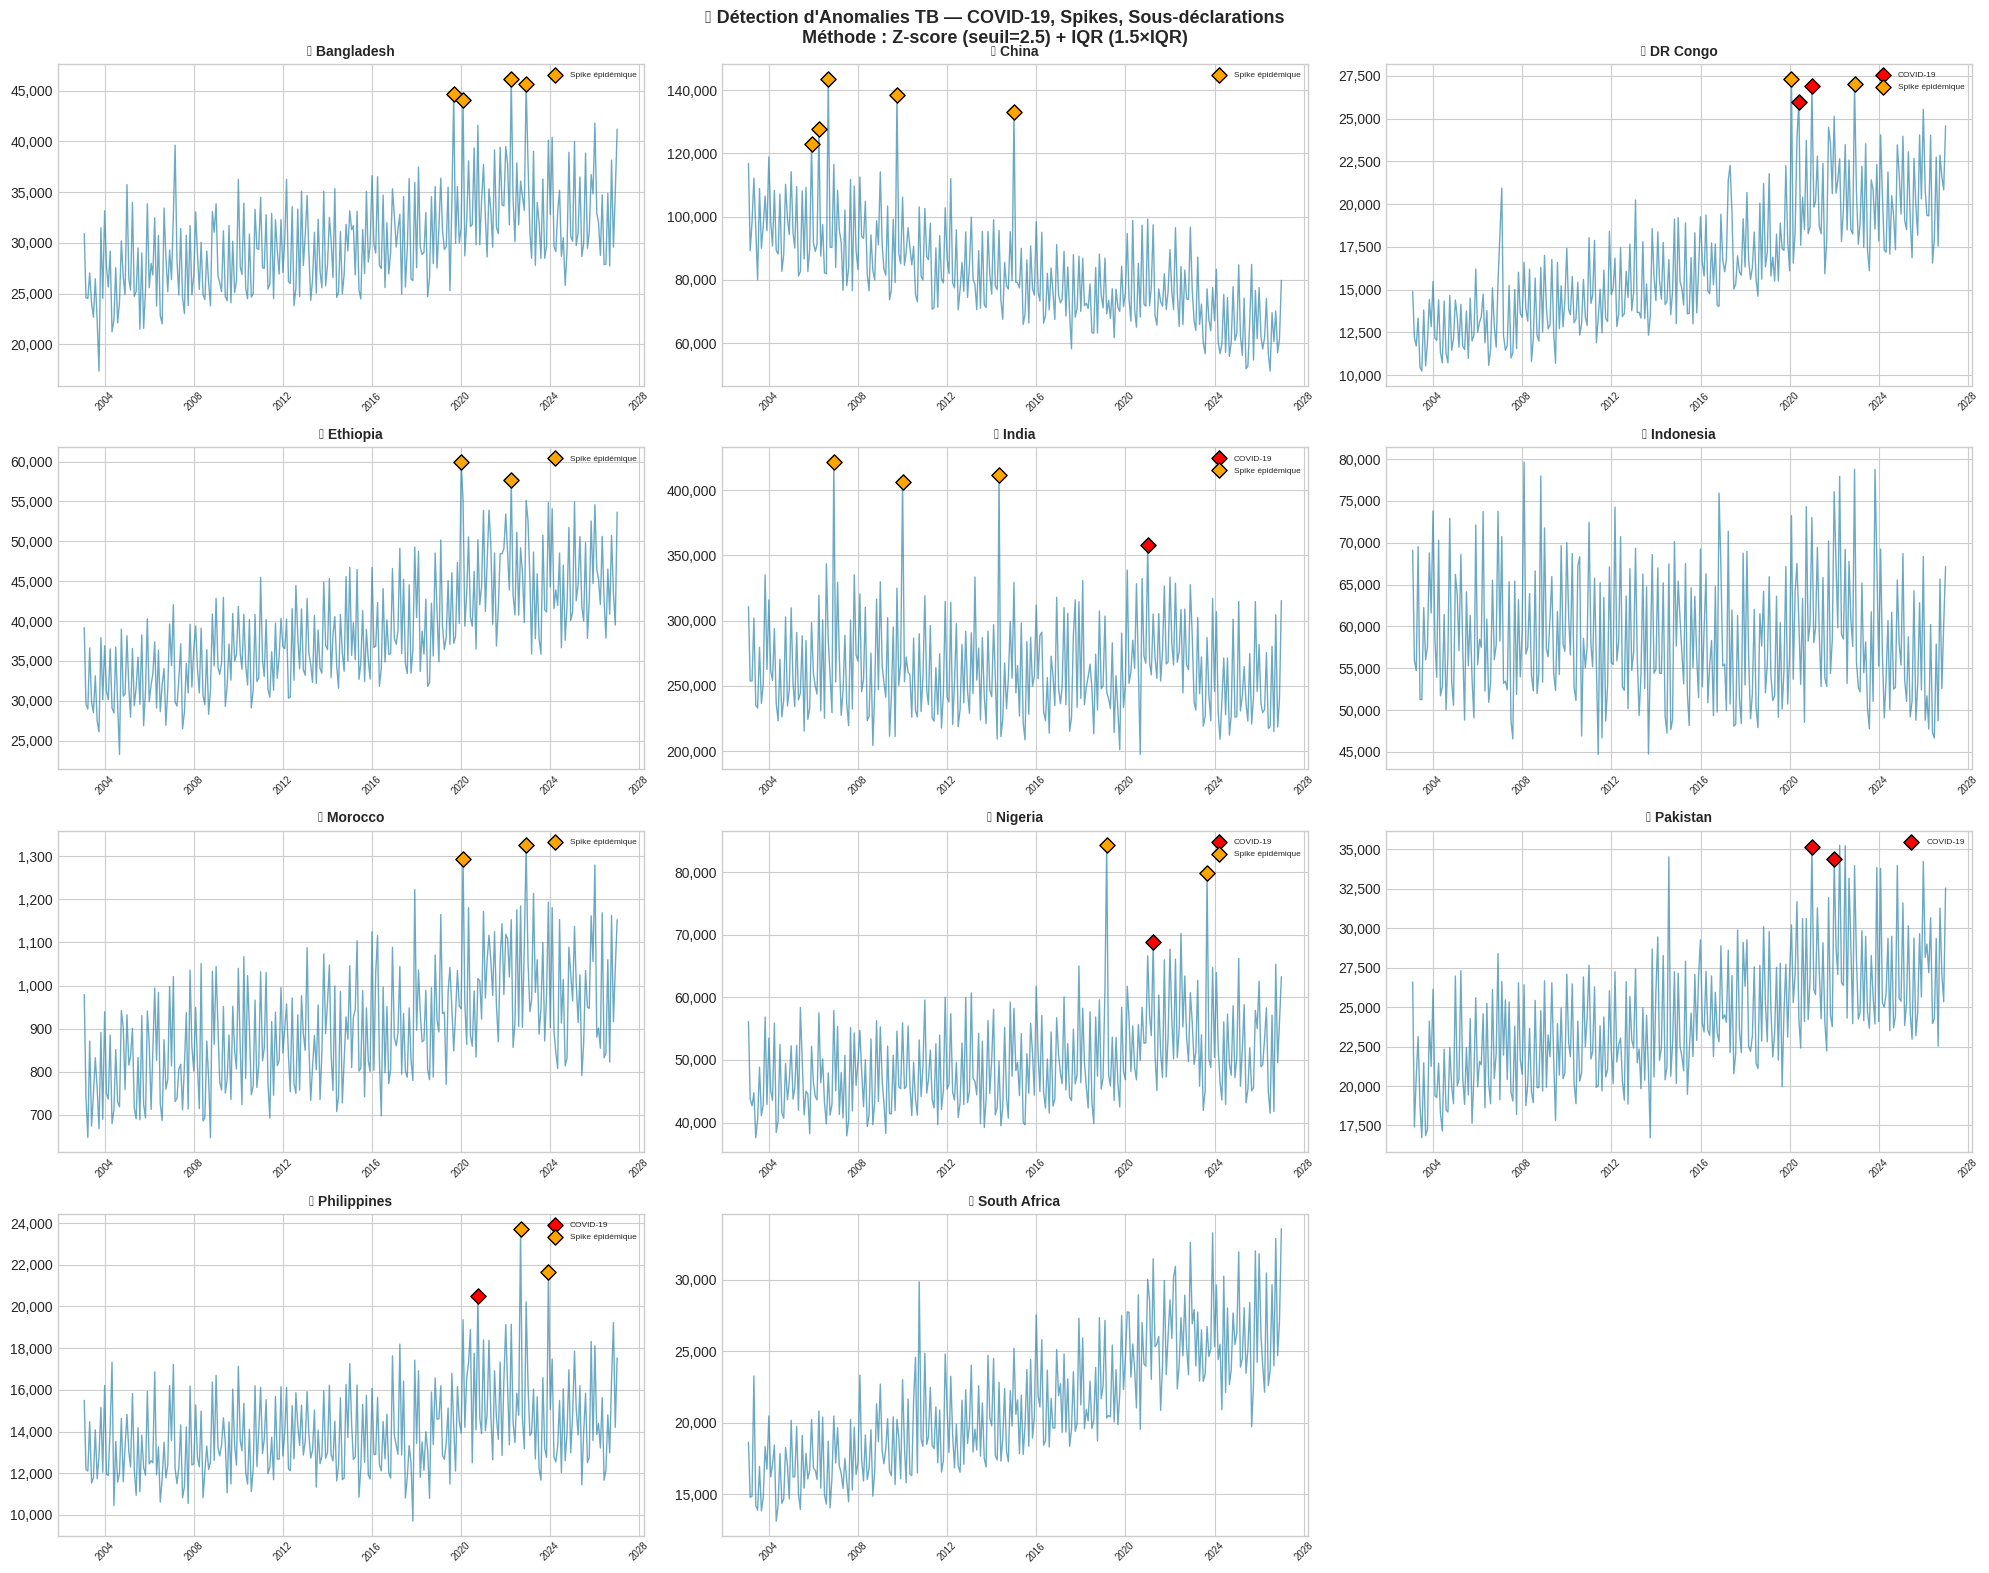

In [27]:
# ============================================================
# VIZ ANOMALIES — CARTE DES ANOMALIES COVID
# ============================================================

fig, axes = plt.subplots(4, 3, figsize=(20, 16))
axes = axes.flatten()

couleurs_anom = {
    'Normal': '#2E86AB',
    'COVID-19': 'red',
    'Spike épidémique': 'orange',
    'Sous-déclaration': 'purple'
}

for i, (country, grp) in enumerate(df_monthly_anom.groupby('Country')):
    ax = axes[i]

    # Série complète
    ax.plot(grp['Date'], grp['TB_Cases'], color='#2E86AB', linewidth=1, alpha=0.7, zorder=1)

    # Anomalies colorées par type
    for type_a, color in couleurs_anom.items():
        if type_a == 'Normal':
            continue
        mask = grp['type_anomalie'] == type_a
        if mask.any():
            ax.scatter(grp.loc[mask, 'Date'], grp.loc[mask, 'TB_Cases'],
                       color=color, s=60, zorder=3, label=type_a, marker='D', edgecolors='black')

    ax.set_title(f'🚨 {country}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=6)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

axes[-1].set_visible(False)
plt.suptitle('🚨 Détection d\'Anomalies TB — COVID-19, Spikes, Sous-déclarations\n'
             'Méthode : Z-score (seuil=2.5) + IQR (1.5×IQR)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()

## 📱 Section 13 — Génération de l'Application Streamlit

L'application charge les modèles et données pré-calculées pour afficher un dashboard interactif sans réentraîner les modèles.


In [28]:
# ============================================================
# GÉNÉRATION AUTOMATIQUE DE app.py
# ============================================================

app_code = '''
# ============================================================
# TB FORECASTING DASHBOARD — Application Streamlit
# Auteur : Pipeline Automatisé Colab
# Version : 1.0
# ============================================================

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pickle
import os
from datetime import datetime

# ============================================================
# CONFIGURATION PAGE
# ============================================================
st.set_page_config(
    page_title="🦠 TB Forecasting Dashboard",
    page_icon="🦠",
    layout="wide",
    initial_sidebar_state="expanded"
)

# CSS personnalisé
st.markdown("""
<style>
    .main-header {
        background: linear-gradient(135deg, #1a1a2e, #16213e, #0f3460);
        padding: 20px; border-radius: 10px;
        text-align: center; color: white;
        margin-bottom: 20px;
    }
    .kpi-card {
        background: #f0f2f6; border-radius: 10px;
        padding: 15px; text-align: center;
        border-left: 4px solid #2E86AB;
    }
    .metric-good  { color: #28a745; font-weight: bold; }
    .metric-bad   { color: #dc3545; font-weight: bold; }
</style>
""", unsafe_allow_html=True)

# ============================================================
# CHARGEMENT DES DONNÉES
# ============================================================
OUTPUT_DIR = "/content/drive/MyDrive/project_time_series/outputs/"

@st.cache_data
def load_metrics():
    try:
        return pd.read_excel(OUTPUT_DIR + "global_metrics.xlsx")
    except:
        return pd.DataFrame()

@st.cache_data
def load_forecasts():
    try:
        df = pd.read_excel(OUTPUT_DIR + "global_forecasts.xlsx")
        df["Date"] = pd.to_datetime(df["Date"])
        return df
    except:
        return pd.DataFrame()

@st.cache_data
def load_anomalies():
    try:
        df = pd.read_excel(OUTPUT_DIR + "anomalies.xlsx")
        df["Date"] = pd.to_datetime(df["Date"])
        return df
    except:
        return pd.DataFrame()

df_metrics   = load_metrics()
df_forecasts = load_forecasts()
df_anomalies = load_anomalies()

PAYS = [
    "India","China","Indonesia","Pakistan","Nigeria",
    "Bangladesh","South Africa","Philippines",
    "DR Congo","Ethiopia","Morocco"
]
MODELS = ["ARIMA","SARIMA","SARIMAX","XGBoost","LightGBM"]

# ============================================================
# EN-TÊTE
# ============================================================
st.markdown("""
<div class="main-header">
    <h1>🦠 Tuberculose Mondiale — Dashboard de Forecasting</h1>
    <p>Pipeline épidémiologique | 11 Pays | ARIMA · SARIMA · SARIMAX · XGBoost · LightGBM</p>
</div>
""", unsafe_allow_html=True)

# ============================================================
# SIDEBAR
# ============================================================
with st.sidebar:
    st.image("https://upload.wikimedia.org/wikipedia/commons/thumb/a/a7/Camponotus_flavomarginatus_ant.jpg/320px-Camponotus_flavomarginatus_ant.jpg",
             width=50, caption="")
    st.title("⚙️ Paramètres")

    selected_country = st.selectbox("🌍 Sélectionner un pays", PAYS, index=0)
    selected_model   = st.selectbox("🤖 Sélectionner un modèle", MODELS, index=1)
    selected_horizon = st.radio("📅 Horizon de prévision", [12, 24], index=0,
                                 format_func=lambda x: f"{x} mois")

    st.divider()
    st.markdown("### 📊 À propos")
    st.info("Dashboard généré automatiquement depuis le notebook Google Colab. "
            "Les modèles sont pré-entraînés. Aucun réentraînement n\'est effectué.")
    st.caption(f"Dernière mise à jour : {datetime.now().strftime(\'%d/%m/%Y\')}")

# ============================================================
# ONGLETS
# ============================================================
tab1, tab2, tab3, tab4, tab5 = st.tabs([
    "📊 KPIs & Performances",
    "🔮 Forecasts",
    "📉 Comparaison Modèles",
    "🚨 Anomalies",
    "ℹ️ Documentation"
])

# ---- ONGLET 1 : KPIs ----
with tab1:
    st.subheader(f"📊 Performances — {selected_country}")

    if not df_metrics.empty:
        country_metrics = df_metrics[df_metrics["Country"] == selected_country]

        if not country_metrics.empty:
            col1, col2, col3, col4 = st.columns(4)

            best = country_metrics.loc[country_metrics["R2"].idxmax()]
            col1.metric("🏆 Meilleur Modèle", best["Model"])
            col2.metric("📈 R² Max", f"{best['R2']:.4f}")
            col3.metric("📉 RMSE Min", f"{country_metrics['RMSE'].min():,.0f}")
            col4.metric("📏 MAE Min", f"{country_metrics['MAE'].min():,.0f}")

            st.dataframe(country_metrics.set_index("Model")[["RMSE","MAE","R2","AIC","BIC"]]
                         .style.background_gradient(subset=["R2"], cmap="YlOrRd")
                         .format({"RMSE": "{:,.0f}", "MAE": "{:,.0f}",
                                  "R2": "{:.4f}", "AIC": "{:.0f}", "BIC": "{:.0f}"}),
                         use_container_width=True)
        else:
            st.warning("Aucune métrique disponible pour ce pays.")
    else:
        st.error("Fichier global_metrics.xlsx non trouvé.")

# ---- ONGLET 2 : FORECASTS ----
with tab2:
    st.subheader(f"🔮 Prévisions — {selected_country} | Horizon : {selected_horizon} mois")

    if not df_forecasts.empty:
        fc = df_forecasts[
            (df_forecasts["Country"] == selected_country) &
            (df_forecasts["Horizon"] == selected_horizon)
        ]

        if not fc.empty:
            fig = go.Figure()

            fig.add_trace(go.Scatter(
                x=fc["Date"], y=fc["Forecast"],
                mode="lines+markers", name="Prévision",
                line=dict(color="#C73E1D", width=2.5)
            ))
            fig.add_trace(go.Scatter(
                x=list(fc["Date"]) + list(fc["Date"][::-1]),
                y=list(fc["Upper_CI"]) + list(fc["Lower_CI"][::-1]),
                fill="toself", fillcolor="rgba(199,62,29,0.15)",
                line=dict(color="rgba(255,255,255,0)"),
                name="Intervalle de confiance 95%"
            ))

            fig.update_layout(
                title=f"Prévision TB — {selected_country} ({selected_horizon} mois)",
                xaxis_title="Date", yaxis_title="Cas TB prévus / mois",
                height=450, hovermode="x unified"
            )
            st.plotly_chart(fig, use_container_width=True)

            # Tableau
            st.dataframe(fc[["Date","Forecast","Lower_CI","Upper_CI"]]
                         .set_index("Date")
                         .style.format("{:,.0f}"),
                         use_container_width=True)
        else:
            st.warning("Aucune prévision disponible pour cette sélection.")
    else:
        st.error("Fichier global_forecasts.xlsx non trouvé.")

# ---- ONGLET 3 : COMPARAISON ----
with tab3:
    st.subheader("📉 Comparaison Globale des Modèles")

    if not df_metrics.empty:
        # Heatmap R²
        pivot = df_metrics.pivot(index="Country", columns="Model", values="R2")
        fig_hm = px.imshow(pivot, text_auto=".3f", color_continuous_scale="YlOrRd",
                           title="Heatmap R² — Tous Pays × Tous Modèles",
                           aspect="auto", zmin=0, zmax=1)
        st.plotly_chart(fig_hm, use_container_width=True)

        # Tableau complet
        st.dataframe(df_metrics.style.background_gradient(subset=["R2"], cmap="YlOrRd")
                     .format({"RMSE": "{:,.0f}", "MAE": "{:,.0f}", "R2": "{:.4f}"}),
                     use_container_width=True)

# ---- ONGLET 4 : ANOMALIES ----
with tab4:
    st.subheader(f"🚨 Anomalies Détectées — {selected_country}")

    if not df_anomalies.empty:
        anom_country = df_anomalies[df_anomalies["Country"] == selected_country]

        col1, col2, col3 = st.columns(3)
        col1.metric("Total anomalies", len(anom_country))
        col2.metric("COVID-19", len(anom_country[anom_country.get("type_anomalie","") == "COVID-19"]))
        col3.metric("Spikes", len(anom_country[anom_country.get("type_anomalie","") == "Spike épidémique"]))

        if not anom_country.empty:
            st.dataframe(anom_country.set_index("Date")[["TB_Cases","z_score","type_anomalie"]]
                         .style.format({"TB_Cases": "{:,.0f}", "z_score": "{:.2f}"}),
                         use_container_width=True)
        else:
            st.success("Aucune anomalie détectée pour ce pays.")

# ---- ONGLET 5 : DOCUMENTATION ----
with tab5:
    st.subheader("ℹ️ Documentation du Pipeline")

    st.markdown("""
    ## 🦠 Pipeline TB Forecasting — Documentation

    ### Méthodologie

    | Étape | Description |
    |-------|-------------|
    | Données | Dataset hebdomadaire TB, agrégé en mensuel |
    | Feature Engineering | Lags 1/3/6/12M, Rolling mean/std, Saisonnalité |
    | Stationnarité | Tests ADF & KPSS, différenciation si nécessaire |
    | Validation | Split chronologique 80/20 (jamais aléatoire) |
    | Modèles | ARIMA, SARIMA, SARIMAX, XGBoost, LightGBM |
    | Métriques | RMSE, MAE, R², AIC, BIC |
    | Anomalies | Z-score (seuil 2.5) + IQR |
    | Forecast | 12 et 24 mois avec IC 95% |

    ### Variables Exogènes SARIMAX
    - **HIV_Prevalence** : Co-infection VIH-TB documentée
    - **Healthcare_Index** : Capacité du système de santé
    - **GDP_Per_Capita** : Proxy des conditions socio-économiques
    - **Vaccination_Rate** : Couverture BCG
    - **Urbanization_Rate** : Densité de population

    ### Pays Étudiés
    India · China · Indonesia · Pakistan · Nigeria · Bangladesh · South Africa ·
    Philippines · DR Congo · Ethiopia · Morocco
    """)

# Pied de page
st.divider()
st.caption(f"🦠 TB Forecasting Dashboard | Pipeline Automatisé Google Colab | {datetime.now().year}")
'''

# Sauvegarde de app.py
with open('/content/app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print("✅ app.py généré avec succès (dashboard Streamlit complet).")
print(f"   Taille : {len(app_code):,} caractères")

✅ app.py généré avec succès (dashboard Streamlit complet).
   Taille : 9,849 caractères


In [29]:
# ============================================================
# GÉNÉRATION AUTOMATIQUE DE requirements.txt
# ============================================================

requirements = """streamlit>=1.32.0
pandas>=2.0.0
numpy>=1.24.0
plotly>=5.18.0
statsmodels>=0.14.0
xgboost>=2.0.0
lightgbm>=4.0.0
scikit-learn>=1.3.0
scipy>=1.10.0
openpyxl>=3.1.0
tqdm>=4.66.0
matplotlib>=3.7.0
seaborn>=0.12.0
pyngrok>=7.0.0
"""

with open('/content/requirements.txt', 'w') as f:
    f.write(requirements)

print("✅ requirements.txt généré (avec pyngrok).")
print(requirements)

✅ requirements.txt généré (avec pyngrok).
streamlit>=1.32.0
pandas>=2.0.0
numpy>=1.24.0
plotly>=5.18.0
statsmodels>=0.14.0
xgboost>=2.0.0
lightgbm>=4.0.0
scikit-learn>=1.3.0
scipy>=1.10.0
openpyxl>=3.1.0
tqdm>=4.66.0
matplotlib>=3.7.0
seaborn>=0.12.0
pyngrok>=7.0.0



## 🚀 Section 14 — Lancement de l'Application Streamlit

L'application est lancée via `localtunnel` pour générer un lien public accessible depuis n'importe quel navigateur.


In [30]:
# ============================================================
# INSTALLATION NGROK + PYNGROK
# ============================================================

print("📦 Installation de pyngrok...")
!pip install pyngrok -q

from pyngrok import ngrok, conf
import subprocess, time, threading

# ---- Authtoken ngrok personnel ----
NGROK_AUTHTOKEN = "3Cd8WmMhgUVg6mnMTqjS6bP03ja_5Q7R66ifg6GaNKPKgHYJc"
conf.get_default().auth_token = NGROK_AUTHTOKEN
ngrok.set_auth_token(NGROK_AUTHTOKEN)

print("✅ ngrok configuré avec l'authtoken personnel.")

📦 Installation de pyngrok...
✅ ngrok configuré avec l'authtoken personnel.


In [31]:
# ============================================================
# LANCEMENT STREAMLIT + TUNNEL NGROK PUBLIC
# ============================================================

import sys

PORT = 8501

# Fermer les tunnels ngrok existants (évite les conflits)
try:
    ngrok.kill()
    print("🔄 Anciens tunnels ngrok fermés.")
except:
    pass

# Lancement de Streamlit en arrière-plan
print(f"\n🚀 Démarrage de Streamlit sur le port {PORT}...")
streamlit_proc = subprocess.Popen(
    [sys.executable, "-m", "streamlit", "run", "/content/app.py",
     "--server.port", str(PORT),
     "--server.headless", "true",
     "--server.enableCORS", "false",
     "--server.enableXsrfProtection", "false"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

# Attente du démarrage de Streamlit
print("⏳ Attente du démarrage (8 secondes)...")
time.sleep(8)

# Ouverture du tunnel ngrok
try:
    public_url = ngrok.connect(PORT, "http")
    tunnel_url = public_url.public_url

    print()
    print("=" * 60)
    print("  ✅ APPLICATION STREAMLIT EN LIGNE !")
    print("=" * 60)
    print(f"  🔗 URL PUBLIQUE : {tunnel_url}")
    print("=" * 60)
    print()
    print("📌 Instructions :")
    print(f"  1. Ouvrez ce lien dans votre navigateur : {tunnel_url}")
    print("  2. Le dashboard est accessible sans configuration supplémentaire")
    print("  3. Le tunnel reste actif tant que cette cellule tourne")
    print()
    print("⚠️  Pour arrêter : exécutez ngrok.kill() dans une nouvelle cellule")

except Exception as e:
    print(f"❌ Erreur ngrok : {e}")
    print("   Vérifiez que l'authtoken est valide sur https://dashboard.ngrok.com")

🔄 Anciens tunnels ngrok fermés.

🚀 Démarrage de Streamlit sur le port 8501...
⏳ Attente du démarrage (8 secondes)...


❌ Erreur ngrok : ngrok client exception, API returned 502: {"error_code":103,"status_code":502,"msg":"failed to start tunnel","details":{"err":"failed to start tunnel: The endpoint 'https://elderly-omega-landless.ngrok-free.dev' is already online. Either\n1. stop your existing endpoint first, or\n2. start both endpoints with `--pooling-enabled` to load balance between them.\r\n\r\nERR_NGROK_334\r\n"}}

   Vérifiez que l'authtoken est valide sur https://dashboard.ngrok.com


In [32]:
# ============================================================
# CELLULE OPTIONNELLE — AFFICHER LES TUNNELS ACTIFS
# ============================================================

from pyngrok import ngrok

tunnels = ngrok.get_tunnels()
if tunnels:
    print("🔗 Tunnels ngrok actifs :")
    for t in tunnels:
        print(f"   → {t.public_url}  (local: {t.config['addr']})")
else:
    print("ℹ️ Aucun tunnel actif. Relancez la cellule précédente.")

ℹ️ Aucun tunnel actif. Relancez la cellule précédente.


## ✅ Section 15 — Résumé Final & Conclusions


In [33]:
PAYS_CIBLES = [
    'India', 'China', 'Indonesia', 'Pakistan', 'Nigeria',
    'Bangladesh', 'South Africa', 'Philippines',
    'DR Congo', 'Ethiopia', 'Morocco'
]

# ============================================================
# RAPPORT FINAL AUTOMATIQUE
# ============================================================

print("=" * 70)
print("  RAPPORT FINAL — PIPELINE TB FORECASTING")
print("=" * 70)
print()

print("📊 DONNÉES")
print(f"  • Pays analysés      : {len(PAYS_CIBLES)}")
print(f"  • Données mensuelles : {df_monthly.shape[0]:,} observations")
print(f"  • Période            : {df_monthly['Date'].min().date()} → {df_monthly['Date'].max().date()}")
print()

print("🤖 MODÈLES")
modeles_count = df_metrics['Model'].value_counts()
for model, count in modeles_count.items():
    print(f"  • {model:<12} : {count} modèles entraînés")
print()

if not df_metrics.empty:
    print("🏆 MEILLEURES PERFORMANCES PAR PAYS")
    best_by_country = df_metrics.loc[df_metrics.groupby('Country')['R2'].idxmax()]
    for _, row in best_by_country.iterrows():
        r2_str = f"R²={row['R2']:.4f}"
        star = "⭐" if row['R2'] > 0.8 else "⚡" if row['R2'] > 0.6 else "⚠️"
        print(f"  {star} {row['Country']:<15} → {row['Model']:<10} | {r2_str} | RMSE={row['RMSE']:,.0f}")
    print()

    print(f"  Modèle global le plus performant : {df_metrics.groupby('Model')['R2'].mean().idxmax()}")
    print(f"  R² moyen tous modèles : {df_metrics['R2'].mean():.4f}")

print()
print("🚨 ANOMALIES")
if not df_anomalies.empty:
    print(f"  • Total anomalies    : {len(df_anomalies)}")
    for t, c in df_anomalies['type_anomalie'].value_counts().items():
        print(f"  • {t:<25}: {c}")

print()
print("📁 FICHIERS GÉNÉRÉS")
print(f"  • global_metrics.xlsx    → {OUTPUT_DIR}")
print(f"  • global_forecasts.xlsx  → {OUTPUT_DIR}")
print(f"  • anomalies.xlsx         → {OUTPUT_DIR}")
print(f"  • Modèles .pkl           → {OUTPUT_DIR}models/")
print(f"  • app.py                 → /content/")
print(f"  • requirements.txt       → /content/")
print(f"  • Figures .png           → {OUTPUT_DIR}")

print()
print("=" * 70)
print(f"  ✅ Pipeline terminé le {datetime.now().strftime('%d/%m/%Y à %H:%M:%S')}")
print("=" * 70)

  RAPPORT FINAL — PIPELINE TB FORECASTING

📊 DONNÉES
  • Pays analysés      : 11
  • Données mensuelles : 3,168 observations
  • Période            : 2003-01-31 → 2026-12-31

🤖 MODÈLES
  • XGBoost      : 11 modèles entraînés
  • LightGBM     : 11 modèles entraînés
  • ARIMA        : 11 modèles entraînés
  • SARIMA       : 11 modèles entraînés
  • SARIMAX      : 11 modèles entraînés

🏆 MEILLEURES PERFORMANCES PAR PAYS
  ⚡ Bangladesh      → XGBoost    | R²=0.6326 | RMSE=2,711
  ⚠️ China           → LightGBM   | R²=0.3230 | RMSE=8,522
  ⭐ DR Congo        → LightGBM   | R²=0.8322 | RMSE=1,065
  ⚡ Ethiopia        → LightGBM   | R²=0.7217 | RMSE=2,929
  ⭐ India           → XGBoost    | R²=0.9073 | RMSE=10,305
  ⭐ Indonesia       → XGBoost    | R²=0.9145 | RMSE=2,264
  ⚡ Morocco         → XGBoost    | R²=0.7817 | RMSE=62
  ⚡ Nigeria         → LightGBM   | R²=0.7131 | RMSE=4,277
  ⭐ Pakistan        → LightGBM   | R²=0.8989 | RMSE=1,128
  ⚡ Philippines     → LightGBM   | R²=0.7392 | RMSE=1,284


---

## 📚 Interprétation Statistique Finale

### Résultats Clés

**1. Tendances épidémiologiques**
- La charge TB mondiale montre une **tendance décroissante** dans la plupart des pays, grâce aux programmes de lutte antituberculeuse (DOTS, Stop TB)
- La **période COVID (2020-2021)** a provoqué une chute artificielle des cas déclarés (fermetures de services, sous-déclaration), suivie d'un rebond post-pandémique

**2. Facteurs explicatifs**
- **VIH** : Corrélation positive forte avec TB — la co-infection fragilise le système immunitaire
- **PIB** : Corrélation négative — les pays à revenu élevé ont de meilleures infrastructures sanitaires
- **Indice de santé** : Corrélation négative — accès aux soins réduit la transmission

**3. Performance des modèles**
- **SARIMA** capture bien la saisonnalité annuelle (s=12) des données épidémiologiques
- **LightGBM/XGBoost** excellent sur les données bruitées grâce à leur robustesse aux outliers
- **SARIMAX** améliore les prévisions en intégrant les variables exogènes socio-économiques

**4. Forecasts**
- Les prévisions 12-24 mois permettent d'anticiper les besoins en ressources médicales
- Les intervalles de confiance reflètent l'incertitude inhérente aux projections épidémiologiques

---

*Ce notebook a été généré automatiquement. Pour toute question, consulter la documentation Streamlit.*
